# belief eye neural analysis (simulation data)


## imports

In [22]:
%reload_ext autoreload
%autoreload 2

In [23]:
import sys
import os
from pathlib import Path
import configparser
config = configparser.ConfigParser()
config.read_file(open('privateconfig'))
resdir = Path(config['Datafolder']['data'])
workdir = Path(config['Codefolder']['workspace'])
os.chdir(workdir)

In [24]:
# analysis
from scipy.io import loadmat
from sklearn.decomposition import FastICA
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from sklearn.model_selection import KFold
from sklearn.linear_model import LassoCV, Lasso
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
from sklearn.cross_decomposition import CCA

In [25]:
# misc
import pickle
from collections import defaultdict

In [26]:
from neural_plot_ult import *
import time
tic=time.time()
import warnings
warnings.filterwarnings('ignore')

# load data

## load standard data


In [38]:
def process_one(y):
    related_taskvar=np.array(normalize_z(y))
    mask=(related_taskvar > -4) & (related_taskvar < 4)
    related_taskvar[~mask]=0
    return related_taskvar, mask

def process(rawtaskvar, returnmask=False):
    # normalize each item to 0 mean 1 std
    rawtaskvar=[np.array(normalize_z(y)) for y in rawtaskvar]
    related_taskvar=np.vstack(rawtaskvar).T
    # related_taskvar=np.clip(related_taskvar,-4,4)
    mask=(related_taskvar > -4) & (related_taskvar < 4)
    mask=np.all(mask, axis=1)
    related_taskvar=related_taskvar[mask]
    if returnmask:
        return related_taskvar, mask
    return related_taskvar
def process_list(rawtaskvar, returnmask=False):
    # normalize each item to 0 mean 1 std
    rawtaskvar=[np.array(normalize_z(y)) for y in rawtaskvar]
    mask=[(a > -4) & (a < 4) for a in rawtaskvar]
    mask=np.all(mask)
    related_taskvar=[a[mask] for a in rawtaskvar]
    if returnmask:
        return related_taskvar, mask
    return related_taskvar

# work

In [29]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score
from scipy.ndimage import gaussian_filter1d # For Gaussian smoothing

# --- Load Your Actual Data ---
# Assume 'timedf' is a pandas DataFrame already loaded in your environment
# It should contain columns like 'PPC' (list/array of raw voltage per trial),
# 'belief', and 'eye'.

# Example check (replace with your actual DataFrame name if different)
if 'timedf' not in locals():
     # Try to load placeholder if actual data not found
     print("Warning: DataFrame 'timedf' not found. Using placeholder data.")
     # --- Placeholder Data (REPLACE WITH YOUR ACTUAL DATA LOADING) ---
     rng = np.random.default_rng(42)
     n_samples_orig = 10000 # Time samples
     n_features = 50      # Number of channels/neurons
     sampling_rate = 166 # Hz - Set to user's rate

     belief_signal_true = normalize_z(rng.random(n_samples_orig) * 10)
     eye_signal_true = normalize_z(rng.random(n_samples_orig) * 5)
     belief_signal_correlated = normalize_z(0.7 * belief_signal_true + 0.3 * eye_signal_true + rng.normal(0, 0.5, n_samples_orig))
     eye_signal_correlated = normalize_z(0.3 * belief_signal_true + 0.7 * eye_signal_true + rng.normal(0, 0.5, n_samples_orig))

     # Simulate baseline "voltage" - use lower frequencies consistent with low sampling rate
     voltage_noise = rng.normal(0, 1.0, (n_samples_orig, n_features))
     # Modulate the amplitude based on belief and eye
     belief_mod = belief_signal_correlated[:, np.newaxis] * 0.1 # Weaker belief component
     eye_mod = eye_signal_correlated[:, np.newaxis] * 0.3   # Stronger eye component
     neural_data_raw_voltage_sim = voltage_noise + belief_mod + eye_mod # Simplified simulation

     timedf = pd.DataFrame({
         # Store as list of arrays if that matches user structure, otherwise adjust loading below
         'PPC': list(neural_data_raw_voltage_sim),
         'belief': belief_signal_correlated,
         'eye': eye_signal_correlated
     })
     # --- End Placeholder Data ---
else:
    print("Using provided 'timedf' DataFrame.")


# --- Parameters ---
sampling_rate = 166 # Hz - IMPORTANT: Set this to your actual sampling rate
outlier_threshold_std = 4 # Z-score threshold for removing outliers
gaussian_sigma_samples = 5 # Std deviation of Gaussian kernel in SAMPLES - ADJUST AS NEEDED

# --- Extract Raw Data ---
print("--- Extracting Raw Data from DataFrame ---")
try:
    # This assumes 'PPC' column contains stackable numerical data (e.g., numpy arrays)
    # representing the voltage time series (samples x features/channels).
    # If your structure is different (e.g. list of lists), adjust np.stack.
    neural_data_raw_voltage = np.stack(timedf['PPC'].to_numpy())
    belief_data_present_raw = timedf['belief'].to_numpy()
    eye_data_present_raw = timedf['eye'].to_numpy()
    print(f"Initial shapes: Neural={neural_data_raw_voltage.shape}, Belief={belief_data_present_raw.shape}, Eye={eye_data_present_raw.shape}")
    # Ensure the number of samples aligns between neural and behavioral data
    if neural_data_raw_voltage.shape[0] != belief_data_present_raw.shape[0]:
        raise ValueError("Mismatch in number of samples between neural ('PPC') and belief data.")
    if neural_data_raw_voltage.shape[0] != eye_data_present_raw.shape[0]:
        raise ValueError("Mismatch in number of samples between neural ('PPC') and eye data.")

except KeyError as e:
    raise KeyError(f"Column not found in timedf: {e}. Ensure columns 'PPC', 'belief', 'eye' exist.")
except Exception as e:
    raise TypeError(f"Error processing 'PPC' column. Ensure it contains stackable numerical data (e.g., numpy arrays). Error: {e}")


# --- Helper function for Z-scoring ---
def normalize_z(data):
    """Applies z-score normalization to a 1D array."""
    if isinstance(data, pd.Series):
        data = data.to_numpy()
    # Handle potential NaNs or Infs if necessary before scaling
    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0) # Replace NaN/Inf with 0 before scaling
    scaler = StandardScaler()
    # Check if data std dev is zero
    if np.std(data) < 1e-9:
         # Return zeros or original data if std dev is zero to avoid division error
        print("Warning: Standard deviation is zero during normalization. Returning zeros.")
        return np.zeros_like(data)
    return scaler.fit_transform(data.reshape(-1, 1)).flatten()

# --- Normalize Behavioral Data ---
print("\n--- Normalizing Behavioral Data ---")
belief_data_normalized = normalize_z(belief_data_present_raw)
eye_data_normalized = normalize_z(eye_data_present_raw)

# --- Outlier Removal ---
print(f"\n--- Removing Outliers (Threshold: +/- {outlier_threshold_std} std dev) ---")
task_vars_normalized = np.vstack([belief_data_normalized, eye_data_normalized]).T
# Identify trials where *either* belief or eye exceeds threshold
mask_outliers = (np.abs(task_vars_normalized) < outlier_threshold_std).all(axis=1)

# Apply mask to all data types
neural_data_raw_voltage_cleaned = neural_data_raw_voltage[mask_outliers, :]
belief_data_present = belief_data_normalized[mask_outliers] # Use normalized data for analysis
eye_data_present = eye_data_normalized[mask_outliers]       # Use normalized data for analysis

n_removed = len(belief_data_present_raw) - len(belief_data_present)
print(f"Removed {n_removed} outlier trials ({n_removed / len(belief_data_present_raw) * 100:.2f}%).")
print(f"Data shape after cleaning: Neural={neural_data_raw_voltage_cleaned.shape}, Belief={belief_data_present.shape}, Eye={eye_data_present.shape}")

if len(belief_data_present) == 0:
    raise ValueError("All data removed as outliers. Check data or threshold.")


# =============================================================================
# Gaussian Smoothing of Raw Voltage Data
# =============================================================================
print(f"\n--- Applying Gaussian Smoothing (sigma = {gaussian_sigma_samples} samples) ---")

# Apply Gaussian filter along the time axis (axis=0) for each channel
# mode='reflect' is a reasonable default for handling edges
neural_data_smoothed = gaussian_filter1d(neural_data_raw_voltage_cleaned,
                                         sigma=gaussian_sigma_samples,
                                         axis=0,
                                         mode='reflect')

print("Gaussian smoothing complete.")

# =============================================================================
# Z-score Smoothed Data Per Channel
# =============================================================================
print("Z-scoring smoothed data per channel...")
scaler_smooth = StandardScaler()
# Fit and transform column by column (if features are channels)
# Handle potential zero std dev channels if necessary
neural_data_processed = np.zeros_like(neural_data_smoothed)
for i in range(neural_data_smoothed.shape[1]):
    channel_data = neural_data_smoothed[:, i].reshape(-1, 1)
    if np.std(channel_data) > 1e-9: # Check for non-zero std dev
        neural_data_processed[:, i] = scaler_smooth.fit_transform(channel_data).flatten()
    else:
        print(f"Warning: Channel {i} has zero standard deviation after smoothing. Outputting zeros.")

print("Z-scoring complete.")
print(f"Processed neural data shape: {neural_data_processed.shape}")


# =============================================================================
# Strategy 2: Partial Regression / Residual Analysis with CV on Smoothed Data
# =============================================================================
print("\n--- Strategy 2: Partial Regression / Residual Analysis (with CV on Smoothed Data) ---")

# Ensure target data is in numpy array format (already done after outlier removal)
# belief_data_present = np.array(belief_data_present)
# eye_data_present = np.array(eye_data_present)

# Reshape predictor variables for LinearRegression
eye_data_present_2d = eye_data_present.reshape(-1, 1)
belief_data_present_2d = belief_data_present.reshape(-1, 1)

# Define the cross-validation strategy
n_splits = 5 # Number of folds
# Check if enough samples for n_splits
if len(belief_data_present) < n_splits:
    n_splits = max(2, len(belief_data_present)) # Use LeaveOneOut if samples < 5, or at least 2 splits
    print(f"Warning: Not enough samples for {n_splits} folds. Using n_splits={n_splits}.")

cv = KFold(n_splits=n_splits, shuffle=True, random_state=42) # Use shuffle for random data splits
print(f"Using {n_splits}-Fold Cross-Validation")

# Initialize the base model
lr_model = LinearRegression()

# --- Part A: Does Belief explain Smoothed Data AFTER removing Eye (CV)? ---

print("\nPart A: Analyzing Belief contribution after removing Eye (CV on Smoothed Data)...")

# 1. Get cross-validated predictions for Smoothed Data ~ Eye
print("Step 1: Getting CV predictions for Smoothed Data ~ Eye")
predicted_smooth_from_eye_cv = cross_val_predict(lr_model, eye_data_present_2d, neural_data_processed, cv=cv)

# 2. Calculate Residuals using the CV predictions
print("Step 2: Calculating Smoothed Data residuals based on CV predictions")
smooth_residuals_after_eye_cv = neural_data_processed - predicted_smooth_from_eye_cv

# 3. Can these CV Residuals predict Belief (using CV)?
print("Step 3: Testing if CV Smoothed Residuals (after Eye removed) predict Belief (using CV)")
predicted_belief_from_smooth_residuals_cv = cross_val_predict(lr_model, smooth_residuals_after_eye_cv, belief_data_present, cv=cv)

# Evaluate how well the CV residuals predict belief using R-squared and Pearson r
r2_belief_after_eye_smooth_cv = r2_score(belief_data_present, predicted_belief_from_smooth_residuals_cv)
# Ensure predictions and actual values have same length and are finite
valid_indices_belief = np.isfinite(belief_data_present) & np.isfinite(predicted_belief_from_smooth_residuals_cv)
if np.sum(valid_indices_belief) < 2: # Need at least 2 points for correlation
    print("Warning: Not enough valid data points to calculate Pearson correlation for Belief.")
    r_belief_after_eye_smooth_cv, p_belief_after_eye_smooth_cv = np.nan, np.nan
else:
    r_belief_after_eye_smooth_cv, p_belief_after_eye_smooth_cv = pearsonr(belief_data_present[valid_indices_belief], predicted_belief_from_smooth_residuals_cv[valid_indices_belief])


print(f"  Cross-Validated R-squared (Smoothed Residuals [after Eye] -> Belief): {r2_belief_after_eye_smooth_cv:.4f}")
print(f"  Cross-Validated Pearson r (Actual Belief vs CV Predicted Belief [from Smoothed Residuals]): {r_belief_after_eye_smooth_cv:.4f}, p={p_belief_after_eye_smooth_cv:.2e}")


# --- Part B: Symmetric Check - Does Eye explain Smoothed Data AFTER removing Belief (CV)? ---

print("\nPart B: Analyzing Eye contribution after removing Belief (CV on Smoothed Data)...")

# 1. Get cross-validated predictions for Smoothed Data ~ Belief
print("Step 1: Getting CV predictions for Smoothed Data ~ Belief")
predicted_smooth_from_belief_cv = cross_val_predict(lr_model, belief_data_present_2d, neural_data_processed, cv=cv)

# 2. Calculate Residuals using the CV predictions
print("Step 2: Calculating Smoothed Data residuals based on CV predictions")
smooth_residuals_after_belief_cv = neural_data_processed - predicted_smooth_from_belief_cv

# 3. Can these CV Residuals predict Eye (using CV)?
print("Step 3: Testing if CV Smoothed Residuals (after Belief removed) predict Eye (using CV)")
predicted_eye_from_smooth_residuals_cv = cross_val_predict(lr_model, smooth_residuals_after_belief_cv, eye_data_present, cv=cv)

# Evaluate how well the CV residuals predict eye using R-squared and Pearson r
r2_eye_after_belief_smooth_cv = r2_score(eye_data_present, predicted_eye_from_smooth_residuals_cv)
# Ensure predictions and actual values have same length and are finite
valid_indices_eye = np.isfinite(eye_data_present) & np.isfinite(predicted_eye_from_smooth_residuals_cv)
if np.sum(valid_indices_eye) < 2: # Need at least 2 points for correlation
     print("Warning: Not enough valid data points to calculate Pearson correlation for Eye.")
     r_eye_after_belief_smooth_cv, p_eye_after_belief_smooth_cv = np.nan, np.nan
else:
    r_eye_after_belief_smooth_cv, p_eye_after_belief_smooth_cv = pearsonr(eye_data_present[valid_indices_eye], predicted_eye_from_smooth_residuals_cv[valid_indices_eye])


print(f"  Cross-Validated R-squared (Smoothed Residuals [after Belief] -> Eye): {r2_eye_after_belief_smooth_cv:.4f}")
print(f"  Cross-Validated Pearson r (Actual Eye vs CV Predicted Eye [from Smoothed Residuals]): {r_eye_after_belief_smooth_cv:.4f}, p={p_eye_after_belief_smooth_cv:.2e}")


# --- Plotting the key cross-validated result (Part A on Smoothed Data) ---
print("\nGenerating plot for Part A cross-validated result (on Smoothed Data)...")
fig_strategy2_cv_smooth, ax_strategy2_cv_smooth = plt.subplots(figsize=(7, 7))

# Scatter plot: Actual belief vs Belief predicted using CV from eye-removed smoothed residuals
# Use only valid indices for plotting if NaNs were generated
ax_strategy2_cv_smooth.scatter(belief_data_present[valid_indices_belief], predicted_belief_from_smooth_residuals_cv[valid_indices_belief], alpha=0.3, s=15, label='CV Predictions')

# Add line of best fit using only valid points
if np.sum(valid_indices_belief) >= 2:
    m_s2_cv_smooth, c_s2_cv_smooth = np.polyfit(belief_data_present[valid_indices_belief], predicted_belief_from_smooth_residuals_cv[valid_indices_belief], 1)
    ax_strategy2_cv_smooth.plot(belief_data_present[valid_indices_belief], m_s2_cv_smooth*belief_data_present[valid_indices_belief] + c_s2_cv_smooth, color='red', linewidth=1.5, label=f'Best fit (CV r={r_belief_after_eye_smooth_cv:.3f})')
else:
     ax_strategy2_cv_smooth.plot([], [], color='red', linewidth=1.5, label=f'Best fit (CV r=N/A)')


# Add identity line
if np.sum(valid_indices_belief) > 0:
    valid_belief = belief_data_present[valid_indices_belief]
    valid_pred_belief = predicted_belief_from_smooth_residuals_cv[valid_indices_belief]
    lims_cv_smooth = [min(np.min(valid_belief), np.min(valid_pred_belief)),
                      max(np.max(valid_belief), np.max(valid_pred_belief))]
    padding = (lims_cv_smooth[1] - lims_cv_smooth[0]) * 0.05
    lims_cv_smooth = [lims_cv_smooth[0] - padding, lims_cv_smooth[1] + padding]
else:
    lims_cv_smooth = [-1, 1] # Default limits

ax_strategy2_cv_smooth.plot(lims_cv_smooth, lims_cv_smooth, 'k--', alpha=0.75, zorder=0, label='Identity line (y=x)')
ax_strategy2_cv_smooth.set_xlim(lims_cv_smooth)
ax_strategy2_cv_smooth.set_ylim(lims_cv_smooth)


# Add labels and title
ax_strategy2_cv_smooth.set_xlabel('Actual Belief (Normalized)')
ax_strategy2_cv_smooth.set_ylabel('Cross-Validated Predicted Belief\n(from Smoothed Residuals after removing Eye)')
ax_strategy2_cv_smooth.set_title(f'Predicting Belief from Eye-Removed Smoothed Voltage (CV, sigma={gaussian_sigma_samples})\nCV $R^2 = {r2_belief_after_eye_smooth_cv:.4f}$')
ax_strategy2_cv_smooth.legend()
ax_strategy2_cv_smooth.grid(True, linestyle='--', alpha=0.5)
# ax_strategy2_cv_smooth.axis('equal') # Keep axes equal
plt.tight_layout()
plt.show()

print("\nStrategy 2 Analysis with Gaussian Smoothing and Cross-Validation Complete.")


TypeError: can't multiply sequence by non-int of type 'float'

In [30]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score
from scipy.ndimage import gaussian_filter1d # For Gaussian smoothing

# --- Load Your Actual Data ---
# Assume 'timedf' is a pandas DataFrame already loaded in your environment
# It should contain columns like 'PPC' (list/array of raw voltage per trial),
# 'belief', and 'eye'.

# Example check (replace with your actual DataFrame name if different)
if 'timedf' not in locals():
     # Try to load placeholder if actual data not found
     print("Warning: DataFrame 'timedf' not found. Using placeholder data.")
     # --- Placeholder Data (REPLACE WITH YOUR ACTUAL DATA LOADING) ---
     rng = np.random.default_rng(42)
     n_samples_orig = 10000 # Time samples
     n_features = 50      # Number of channels/neurons
     sampling_rate = 166 # Hz - Set to user's rate

     belief_signal_true = normalize_z(rng.random(n_samples_orig) * 10)
     eye_signal_true = normalize_z(rng.random(n_samples_orig) * 5)
     belief_signal_correlated = normalize_z(0.7 * belief_signal_true + 0.3 * eye_signal_true + rng.normal(0, 0.5, n_samples_orig))
     eye_signal_correlated = normalize_z(0.3 * belief_signal_true + 0.7 * eye_signal_true + rng.normal(0, 0.5, n_samples_orig))

     voltage_noise = rng.normal(0, 1.0, (n_samples_orig, n_features))
     belief_mod = belief_signal_correlated[:, np.newaxis] * 0.1
     eye_mod = eye_signal_correlated[:, np.newaxis] * 0.3
     neural_data_raw_voltage_sim = voltage_noise + belief_mod + eye_mod

     timedf = pd.DataFrame({
         'PPC': list(neural_data_raw_voltage_sim),
         'belief': belief_signal_correlated,
         'eye': eye_signal_correlated
     })
     # --- End Placeholder Data ---
else:
    print("Using provided 'timedf' DataFrame.")


# --- Parameters ---
sampling_rate = 166 # Hz - IMPORTANT: Set this to your actual sampling rate
outlier_threshold_std = 4 # Z-score threshold for removing outliers
gaussian_sigma_samples = 5 # Std deviation of Gaussian kernel in SAMPLES

# --- Extract Raw Data ---
print("--- Extracting Raw Data from DataFrame ---")
try:
    neural_data_raw_voltage = np.stack(timedf['PPC'].to_numpy())
    belief_data_present_raw = timedf['belief'].to_numpy()
    eye_data_present_raw = timedf['eye'].to_numpy()
    print(f"Initial shapes: Neural={neural_data_raw_voltage.shape}, Belief={belief_data_present_raw.shape}, Eye={eye_data_present_raw.shape}")
    if neural_data_raw_voltage.shape[0] != belief_data_present_raw.shape[0]:
        raise ValueError("Mismatch in number of samples between neural ('PPC') and belief data.")
    if neural_data_raw_voltage.shape[0] != eye_data_present_raw.shape[0]:
        raise ValueError("Mismatch in number of samples between neural ('PPC') and eye data.")
except KeyError as e:
    raise KeyError(f"Column not found in timedf: {e}. Ensure columns 'PPC', 'belief', 'eye' exist.")
except Exception as e:
    raise TypeError(f"Error processing 'PPC' column. Ensure it contains stackable numerical data. Error: {e}")


# --- Helper function for Z-scoring ---
def normalize_z(data):
    """Applies z-score normalization to a 1D array."""
    if isinstance(data, pd.Series):
        data = data.to_numpy()
    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)
    scaler = StandardScaler()
    if np.std(data) < 1e-9:
        print("Warning: Standard deviation is zero during normalization. Returning zeros.")
        return np.zeros_like(data)
    return scaler.fit_transform(data.reshape(-1, 1)).flatten()

# --- Normalize Behavioral Data ---
print("\n--- Normalizing Behavioral Data ---")
belief_data_normalized = normalize_z(belief_data_present_raw)
eye_data_normalized = normalize_z(eye_data_present_raw)

# --- Outlier Removal ---
print(f"\n--- Removing Outliers (Threshold: +/- {outlier_threshold_std} std dev) ---")
task_vars_normalized = np.vstack([belief_data_normalized, eye_data_normalized]).T
mask_outliers = (np.abs(task_vars_normalized) < outlier_threshold_std).all(axis=1)

neural_data_raw_voltage_cleaned = neural_data_raw_voltage[mask_outliers, :]
belief_data_present = belief_data_normalized[mask_outliers]
eye_data_present = eye_data_normalized[mask_outliers]

n_removed = len(belief_data_present_raw) - len(belief_data_present)
print(f"Removed {n_removed} outlier trials ({n_removed / len(belief_data_present_raw) * 100:.2f}%).")
print(f"Data shape after cleaning: Neural={neural_data_raw_voltage_cleaned.shape}, Belief={belief_data_present.shape}, Eye={eye_data_present.shape}")

if len(belief_data_present) == 0:
    raise ValueError("All data removed as outliers. Check data or threshold.")

# =============================================================================
# Gaussian Smoothing of Raw Voltage Data
# =============================================================================
print(f"\n--- Applying Gaussian Smoothing (sigma = {gaussian_sigma_samples} samples) ---")
neural_data_smoothed = gaussian_filter1d(neural_data_raw_voltage_cleaned,
                                         sigma=gaussian_sigma_samples,
                                         axis=0,
                                         mode='reflect')
print("Gaussian smoothing complete.")

# =============================================================================
# Z-score Smoothed Data Per Channel
# =============================================================================
print("Z-scoring smoothed data per channel...")
scaler_smooth = StandardScaler()
neural_data_processed = np.zeros_like(neural_data_smoothed)
for i in range(neural_data_smoothed.shape[1]):
    channel_data = neural_data_smoothed[:, i].reshape(-1, 1)
    if np.std(channel_data) > 1e-9:
        neural_data_processed[:, i] = scaler_smooth.fit_transform(channel_data).flatten()
    else:
        print(f"Warning: Channel {i} has zero standard deviation after smoothing. Outputting zeros.")
print("Z-scoring complete.")
print(f"Processed neural data shape: {neural_data_processed.shape}")

# =============================================================================
# Calculate Cross-Validated Residuals After Removing Eye (from Strategy 2, Part A)
# =============================================================================
print("\n--- Recalculating CV Residuals After Removing Eye (Smoothed Data) ---")

# Reshape eye data for prediction
eye_data_present_2d = eye_data_present.reshape(-1, 1)

# Define the cross-validation strategy
n_splits = 5
if len(belief_data_present) < n_splits:
    n_splits = max(2, len(belief_data_present))
cv = KFold(n_splits=n_splits, shuffle=True, random_state=42)
print(f"Using {n_splits}-Fold Cross-Validation")

# Initialize the base model
lr_model = LinearRegression()

# 1. Get cross-validated predictions for Smoothed Data ~ Eye
print("Step 1: Getting CV predictions for Smoothed Data ~ Eye")
predicted_smooth_from_eye_cv = cross_val_predict(lr_model, eye_data_present_2d, neural_data_processed, cv=cv)

# 2. Calculate Residuals using the CV predictions
print("Step 2: Calculating Smoothed Data residuals based on CV predictions")
smooth_residuals_after_eye_cv = neural_data_processed - predicted_smooth_from_eye_cv
print("  Calculated smooth_residuals_after_eye_cv")

# =============================================================================
# Cross-Validated Sanity Check: Can CV Residuals (after Eye removed) predict Eye?
# =============================================================================
print("\n--- Cross-Validated Sanity Check: Predicting Eye from Eye-Removed CV Residuals ---")

# 1. Get cross-validated predictions for Eye ~ CV_Residuals_after_Eye
print("Step 1: Getting CV predictions for Eye ~ CV Residuals [after Eye]")
# Use the CV residuals calculated just above to predict the original eye data, using CV again
predicted_eye_from_cv_residuals_cv = cross_val_predict(lr_model, smooth_residuals_after_eye_cv, eye_data_present, cv=cv)

# 2. Evaluate the prediction performance using R2 score and Pearson r
# Compare the actual eye data with the cross-validated predictions from the residuals
print("Step 2: Evaluating prediction performance")
r2_eye_from_cv_residuals_cv = r2_score(eye_data_present, predicted_eye_from_cv_residuals_cv)
print(f"  Cross-Validated R-squared (CV Residuals [after Eye] -> Eye): {r2_eye_from_cv_residuals_cv:.4f} (Expected near 0)")

# Calculate the Pearson correlation
# Ensure predictions and actual values have same length and are finite
valid_indices_eye_sc = np.isfinite(eye_data_present) & np.isfinite(predicted_eye_from_cv_residuals_cv)
if np.sum(valid_indices_eye_sc) < 2: # Need at least 2 points for correlation
     print("Warning: Not enough valid data points to calculate Pearson correlation for Sanity Check.")
     r_eye_from_cv_residuals_cv, p_eye_from_cv_residuals_cv = np.nan, np.nan
else:
    r_eye_from_cv_residuals_cv, p_eye_from_cv_residuals_cv = pearsonr(eye_data_present[valid_indices_eye_sc], predicted_eye_from_cv_residuals_cv[valid_indices_eye_sc])

print(f"  Cross-Validated Pearson r (Actual Eye vs CV Predicted Eye [from CV Residuals]): {r_eye_from_cv_residuals_cv:.4f}, p={p_eye_from_cv_residuals_cv:.2e} (Expected near 0)")


# --- Plotting the Cross-Validated Sanity Check Result ---
print("\nGenerating plot for Cross-Validated Sanity Check result...")
fig_cv_sanity_check, ax_cv_sanity_check = plt.subplots(figsize=(7, 7))

# Scatter plot: Actual eye vs Eye predicted using CV from eye-removed CV residuals
# Use only valid indices for plotting if NaNs were generated
ax_cv_sanity_check.scatter(eye_data_present[valid_indices_eye_sc], predicted_eye_from_cv_residuals_cv[valid_indices_eye_sc], alpha=0.3, s=15, label='CV Predictions')

# Add line of best fit using only valid points (should be near flat)
if np.sum(valid_indices_eye_sc) >= 2:
    m_sc_cv, c_sc_cv = np.polyfit(eye_data_present[valid_indices_eye_sc], predicted_eye_from_cv_residuals_cv[valid_indices_eye_sc], 1)
    ax_cv_sanity_check.plot(eye_data_present[valid_indices_eye_sc], m_sc_cv*eye_data_present[valid_indices_eye_sc] + c_sc_cv, color='red', linewidth=1.5, label=f'Best fit (CV r={r_eye_from_cv_residuals_cv:.3f})')
else:
    ax_cv_sanity_check.plot([], [], color='red', linewidth=1.5, label=f'Best fit (CV r=N/A)')


# Add identity line (y=x) for reference
if np.sum(valid_indices_eye_sc) > 0:
    valid_eye = eye_data_present[valid_indices_eye_sc]
    valid_pred_eye = predicted_eye_from_cv_residuals_cv[valid_indices_eye_sc]
    lims_sc_cv = [min(np.min(valid_eye), np.min(valid_pred_eye)),
                  max(np.max(valid_eye), np.max(valid_pred_eye))]
    padding = (lims_sc_cv[1] - lims_sc_cv[0]) * 0.05
    lims_sc_cv = [lims_sc_cv[0] - padding, lims_sc_cv[1] + padding]
else:
    lims_sc_cv = [-1, 1] # Default limits

ax_cv_sanity_check.plot(lims_sc_cv, lims_sc_cv, 'k--', alpha=0.75, zorder=0, label='Identity line (y=x)')
ax_cv_sanity_check.set_xlim(lims_sc_cv)
ax_cv_sanity_check.set_ylim(lims_sc_cv)


# Add labels and title
ax_cv_sanity_check.set_xlabel('Actual Eye Position (Normalized)')
ax_cv_sanity_check.set_ylabel('Cross-Validated Predicted Eye\n(from Eye-Removed CV Residuals)')
ax_cv_sanity_check.set_title(f'CV Sanity Check: Predicting Eye from Eye-Removed Residuals\nCV $R^2 = {r2_eye_from_cv_residuals_cv:.4f}$') # Use LaTeX for R^2
ax_cv_sanity_check.legend()
ax_cv_sanity_check.grid(True, linestyle='--', alpha=0.5)
# ax_cv_sanity_check.axis('equal') # Keep axes equal
plt.tight_layout()
plt.show()

print("\nCross-Validated Sanity Check Complete.")


TypeError: can't multiply sequence by non-int of type 'float'

In [31]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score
from scipy.ndimage import gaussian_filter1d # For Gaussian smoothing

# --- Load Your Actual Data ---
# Assume 'timedf' is a pandas DataFrame already loaded in your environment
# It should contain columns like 'PPC', 'belief', 'eye', and 'state'.

# Example check (replace with your actual DataFrame name if different)
if 'timedf' not in locals():
     # Try to load placeholder if actual data not found
     print("Warning: DataFrame 'timedf' not found. Using placeholder data.")
     # --- Placeholder Data (REPLACE WITH YOUR ACTUAL DATA LOADING) ---
     rng = np.random.default_rng(42)
     n_samples_orig = 10000 # Time samples
     n_features = 50      # Number of channels/neurons
     sampling_rate = 166 # Hz - Set to user's rate

     belief_signal_true = normalize_z(rng.random(n_samples_orig) * 10)
     eye_signal_true = normalize_z(rng.random(n_samples_orig) * 5)
     # Simulate state as belief + noise
     state_signal_true = normalize_z(belief_signal_true + rng.normal(0, 0.3, n_samples_orig))

     belief_signal_correlated = normalize_z(0.7 * belief_signal_true + 0.3 * eye_signal_true + rng.normal(0, 0.5, n_samples_orig))
     eye_signal_correlated = normalize_z(0.3 * belief_signal_true + 0.7 * eye_signal_true + rng.normal(0, 0.5, n_samples_orig))
     state_signal_correlated = normalize_z(0.7 * state_signal_true + 0.3 * eye_signal_true + rng.normal(0, 0.5, n_samples_orig)) # State also correlated with eye

     voltage_noise = rng.normal(0, 1.0, (n_samples_orig, n_features))
     belief_mod = belief_signal_correlated[:, np.newaxis] * 0.1
     eye_mod = eye_signal_correlated[:, np.newaxis] * 0.3
     # Assume state has weaker neural correlate than belief
     state_mod = state_signal_correlated[:, np.newaxis] * 0.05
     neural_data_raw_voltage_sim = voltage_noise + belief_mod + eye_mod + state_mod

     timedf = pd.DataFrame({
         'PPC': list(neural_data_raw_voltage_sim),
         'belief': belief_signal_correlated,
         'eye': eye_signal_correlated,
         'state': state_signal_correlated # Add state column
     })
     # --- End Placeholder Data ---
else:
    print("Using provided 'timedf' DataFrame.")


# --- Parameters ---
sampling_rate = 166 # Hz - IMPORTANT: Set this to your actual sampling rate
outlier_threshold_std = 4 # Z-score threshold for removing outliers
gaussian_sigma_samples = 5 # Std deviation of Gaussian kernel in SAMPLES

# --- Extract Raw Data ---
print("--- Extracting Raw Data from DataFrame ---")
try:
    neural_data_raw_voltage = np.stack(timedf['PPC'].to_numpy())
    belief_data_present_raw = timedf['belief'].to_numpy()
    eye_data_present_raw = timedf['eye'].to_numpy()
    state_data_present_raw = timedf['state'].to_numpy() # Extract state data
    print(f"Initial shapes: Neural={neural_data_raw_voltage.shape}, Belief={belief_data_present_raw.shape}, Eye={eye_data_present_raw.shape}, State={state_data_present_raw.shape}")

    # Basic shape checks
    if not (neural_data_raw_voltage.shape[0] == belief_data_present_raw.shape[0] == eye_data_present_raw.shape[0] == state_data_present_raw.shape[0]):
        raise ValueError("Mismatch in number of samples between neural ('PPC'), belief, eye, or state data.")

except KeyError as e:
    raise KeyError(f"Column not found in timedf: {e}. Ensure columns 'PPC', 'belief', 'eye', and 'state' exist.")
except Exception as e:
    raise TypeError(f"Error processing data columns. Ensure they contain stackable numerical data. Error: {e}")


# --- Helper function for Z-scoring ---
def normalize_z(data):
    """Applies z-score normalization to a 1D array."""
    if isinstance(data, pd.Series):
        data = data.to_numpy()
    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0) # Replace NaN/Inf with 0 before scaling
    scaler = StandardScaler()
    if np.std(data) < 1e-9:
        print("Warning: Standard deviation is zero during normalization. Returning zeros.")
        return np.zeros_like(data)
    return scaler.fit_transform(data.reshape(-1, 1)).flatten()

# --- Normalize Behavioral Data ---
print("\n--- Normalizing Behavioral Data ---")
belief_data_normalized = normalize_z(belief_data_present_raw)
eye_data_normalized = normalize_z(eye_data_present_raw)
state_data_normalized = normalize_z(state_data_present_raw) # Normalize state data

# --- Outlier Removal (including State) ---
print(f"\n--- Removing Outliers (Threshold: +/- {outlier_threshold_std} std dev for Belief, Eye, AND State) ---")
task_vars_normalized = np.vstack([belief_data_normalized, eye_data_normalized, state_data_normalized]).T
# Remove trial if ANY of the variables exceed threshold
mask_outliers = (np.abs(task_vars_normalized) < outlier_threshold_std).all(axis=1)

# Apply mask to all data types
neural_data_raw_voltage_cleaned = neural_data_raw_voltage[mask_outliers, :]
belief_data_present = belief_data_normalized[mask_outliers] # Use normalized data for analysis
eye_data_present = eye_data_normalized[mask_outliers]       # Use normalized data for analysis
state_data_present = state_data_normalized[mask_outliers]     # Use normalized data for analysis

n_removed = len(belief_data_present_raw) - len(belief_data_present)
print(f"Removed {n_removed} outlier trials ({n_removed / len(belief_data_present_raw) * 100:.2f}%).")
print(f"Data shape after cleaning: Neural={neural_data_raw_voltage_cleaned.shape}, Belief={belief_data_present.shape}, Eye={eye_data_present.shape}, State={state_data_present.shape}")

if len(belief_data_present) == 0:
    raise ValueError("All data removed as outliers. Check data or threshold.")

# =============================================================================
# Gaussian Smoothing of Raw Voltage Data
# =============================================================================
print(f"\n--- Applying Gaussian Smoothing (sigma = {gaussian_sigma_samples} samples) ---")
neural_data_smoothed = gaussian_filter1d(neural_data_raw_voltage_cleaned,
                                         sigma=gaussian_sigma_samples,
                                         axis=0,
                                         mode='reflect')
print("Gaussian smoothing complete.")

# =============================================================================
# Z-score Smoothed Data Per Channel
# =============================================================================
print("Z-scoring smoothed data per channel...")
scaler_smooth = StandardScaler()
neural_data_processed = np.zeros_like(neural_data_smoothed)
for i in range(neural_data_smoothed.shape[1]):
    channel_data = neural_data_smoothed[:, i].reshape(-1, 1)
    if np.std(channel_data) > 1e-9:
        neural_data_processed[:, i] = scaler_smooth.fit_transform(channel_data).flatten()
    else:
        print(f"Warning: Channel {i} has zero standard deviation after smoothing. Outputting zeros.")
print("Z-scoring complete.")
print(f"Processed neural data shape: {neural_data_processed.shape}")

# =============================================================================
# Calculate Cross-Validated Residuals After Removing Eye (from Strategy 2, Part A)
# =============================================================================
print("\n--- Recalculating CV Residuals After Removing Eye (Smoothed Data) ---")

# Reshape eye data for prediction
eye_data_present_2d = eye_data_present.reshape(-1, 1)

# Define the cross-validation strategy
n_splits = 5
if len(belief_data_present) < n_splits:
    n_splits = max(2, len(belief_data_present))
cv = KFold(n_splits=n_splits, shuffle=True, random_state=42)
print(f"Using {n_splits}-Fold Cross-Validation")

# Initialize the base model
lr_model = LinearRegression()

# 1. Get cross-validated predictions for Smoothed Data ~ Eye
print("Step 1: Getting CV predictions for Smoothed Data ~ Eye")
predicted_smooth_from_eye_cv = cross_val_predict(lr_model, eye_data_present_2d, neural_data_processed, cv=cv)

# 2. Calculate Residuals using the CV predictions
print("Step 2: Calculating Smoothed Data residuals based on CV predictions")
smooth_residuals_after_eye_cv = neural_data_processed - predicted_smooth_from_eye_cv
print("  Calculated smooth_residuals_after_eye_cv") # These are the features for the next step

# =============================================================================
# Predict Belief AND State from Eye-Removed Residuals (Cross-Validated)
# =============================================================================
print("\n--- Predicting Belief vs State from Eye-Removed CV Residuals ---")

# --- A: Predict Belief ---
print("A: Predicting Belief from CV Residuals [after Eye]...")
predicted_belief_from_smooth_residuals_cv = cross_val_predict(lr_model, smooth_residuals_after_eye_cv, belief_data_present, cv=cv)

# Evaluate Belief prediction
r2_belief_after_eye_smooth_cv = r2_score(belief_data_present, predicted_belief_from_smooth_residuals_cv)
valid_indices_belief = np.isfinite(belief_data_present) & np.isfinite(predicted_belief_from_smooth_residuals_cv)
if np.sum(valid_indices_belief) < 2:
    print("Warning: Not enough valid data points to calculate Pearson correlation for Belief.")
    r_belief_after_eye_smooth_cv, p_belief_after_eye_smooth_cv = np.nan, np.nan
else:
    r_belief_after_eye_smooth_cv, p_belief_after_eye_smooth_cv = pearsonr(belief_data_present[valid_indices_belief], predicted_belief_from_smooth_residuals_cv[valid_indices_belief])

print(f"  CV R-squared (Residuals -> Belief): {r2_belief_after_eye_smooth_cv:.4f}")
print(f"  CV Pearson r (Actual Belief vs Predicted): {r_belief_after_eye_smooth_cv:.4f}, p={p_belief_after_eye_smooth_cv:.2e}")

# --- B: Predict State ---
print("\nB: Predicting State from CV Residuals [after Eye]...")
predicted_state_from_smooth_residuals_cv = cross_val_predict(lr_model, smooth_residuals_after_eye_cv, state_data_present, cv=cv)

# Evaluate State prediction
r2_state_after_eye_smooth_cv = r2_score(state_data_present, predicted_state_from_smooth_residuals_cv)
valid_indices_state = np.isfinite(state_data_present) & np.isfinite(predicted_state_from_smooth_residuals_cv)
if np.sum(valid_indices_state) < 2:
    print("Warning: Not enough valid data points to calculate Pearson correlation for State.")
    r_state_after_eye_smooth_cv, p_state_after_eye_smooth_cv = np.nan, np.nan
else:
    r_state_after_eye_smooth_cv, p_state_after_eye_smooth_cv = pearsonr(state_data_present[valid_indices_state], predicted_state_from_smooth_residuals_cv[valid_indices_state])

print(f"  CV R-squared (Residuals -> State): {r2_state_after_eye_smooth_cv:.4f}")
print(f"  CV Pearson r (Actual State vs Predicted): {r_state_after_eye_smooth_cv:.4f}, p={p_state_after_eye_smooth_cv:.2e}")


# =============================================================================
# Sanity Check: Can CV Residuals (after Eye removed) predict Eye? (Optional but recommended)
# =============================================================================
print("\n--- Cross-Validated Sanity Check: Predicting Eye from Eye-Removed CV Residuals ---")

predicted_eye_from_cv_residuals_cv = cross_val_predict(lr_model, smooth_residuals_after_eye_cv, eye_data_present, cv=cv)
r2_eye_from_cv_residuals_cv = r2_score(eye_data_present, predicted_eye_from_cv_residuals_cv)
valid_indices_eye_sc = np.isfinite(eye_data_present) & np.isfinite(predicted_eye_from_cv_residuals_cv)
if np.sum(valid_indices_eye_sc) < 2:
     print("Warning: Not enough valid data points for Sanity Check Pearson correlation.")
     r_eye_from_cv_residuals_cv, p_eye_from_cv_residuals_cv = np.nan, np.nan
else:
    r_eye_from_cv_residuals_cv, p_eye_from_cv_residuals_cv = pearsonr(eye_data_present[valid_indices_eye_sc], predicted_eye_from_cv_residuals_cv[valid_indices_eye_sc])

print(f"  CV R-squared (CV Residuals [after Eye] -> Eye): {r2_eye_from_cv_residuals_cv:.4f} (Expected near 0)")
print(f"  CV Pearson r (Actual Eye vs CV Predicted Eye [from CV Residuals]): {r_eye_from_cv_residuals_cv:.4f}, p={p_eye_from_cv_residuals_cv:.2e} (Expected near 0)")


# --- Plotting Comparison (Belief vs State Prediction) ---
print("\nGenerating plot comparing Belief and State prediction from residuals...")
fig_compare, (ax_belief, ax_state) = plt.subplots(1, 2, figsize=(14, 7))
fig_compare.suptitle('Predicting Belief vs State from Eye-Removed Smoothed Voltage (CV)', fontsize=14)

# Belief Plot
if np.sum(valid_indices_belief) > 0:
    ax_belief.scatter(belief_data_present[valid_indices_belief], predicted_belief_from_smooth_residuals_cv[valid_indices_belief], alpha=0.3, s=15, label='CV Predictions')
    if np.sum(valid_indices_belief) >= 2:
        m_belief, c_belief = np.polyfit(belief_data_present[valid_indices_belief], predicted_belief_from_smooth_residuals_cv[valid_indices_belief], 1)
        ax_belief.plot(belief_data_present[valid_indices_belief], m_belief*belief_data_present[valid_indices_belief] + c_belief, color='red', linewidth=1.5, label=f'Best fit (CV r={r_belief_after_eye_smooth_cv:.3f})')
    valid_belief_vals = belief_data_present[valid_indices_belief]
    valid_pred_belief_vals = predicted_belief_from_smooth_residuals_cv[valid_indices_belief]
    lims_belief = [min(np.min(valid_belief_vals), np.min(valid_pred_belief_vals)), max(np.max(valid_belief_vals), np.max(valid_pred_belief_vals))]
    padding_b = (lims_belief[1] - lims_belief[0]) * 0.05
    lims_belief = [lims_belief[0] - padding_b, lims_belief[1] + padding_b]
else:
    lims_belief = [-1, 1]
    ax_belief.text(0.5, 0.5, 'No valid data for belief plot', horizontalalignment='center', verticalalignment='center', transform=ax_belief.transAxes)


ax_belief.plot(lims_belief, lims_belief, 'k--', alpha=0.75, zorder=0, label='Identity line (y=x)')
ax_belief.set_xlim(lims_belief)
ax_belief.set_ylim(lims_belief)
ax_belief.set_xlabel('Actual Belief (Normalized)')
ax_belief.set_ylabel('CV Predicted Belief\n(from Eye-Removed Residuals)')
ax_belief.set_title(f'Belief Prediction\nCV $R^2 = {r2_belief_after_eye_smooth_cv:.4f}$')
ax_belief.legend()
ax_belief.grid(True, linestyle='--', alpha=0.5)
# ax_belief.axis('equal')

# State Plot
if np.sum(valid_indices_state) > 0:
    ax_state.scatter(state_data_present[valid_indices_state], predicted_state_from_smooth_residuals_cv[valid_indices_state], alpha=0.3, s=15, label='CV Predictions')
    if np.sum(valid_indices_state) >= 2:
        m_state, c_state = np.polyfit(state_data_present[valid_indices_state], predicted_state_from_smooth_residuals_cv[valid_indices_state], 1)
        ax_state.plot(state_data_present[valid_indices_state], m_state*state_data_present[valid_indices_state] + c_state, color='blue', linewidth=1.5, label=f'Best fit (CV r={r_state_after_eye_smooth_cv:.3f})') # Different color
    valid_state_vals = state_data_present[valid_indices_state]
    valid_pred_state_vals = predicted_state_from_smooth_residuals_cv[valid_indices_state]
    lims_state = [min(np.min(valid_state_vals), np.min(valid_pred_state_vals)), max(np.max(valid_state_vals), np.max(valid_pred_state_vals))]
    padding_s = (lims_state[1] - lims_state[0]) * 0.05
    lims_state = [lims_state[0] - padding_s, lims_state[1] + padding_s]
else:
    lims_state = [-1, 1]
    ax_state.text(0.5, 0.5, 'No valid data for state plot', horizontalalignment='center', verticalalignment='center', transform=ax_state.transAxes)


ax_state.plot(lims_state, lims_state, 'k--', alpha=0.75, zorder=0, label='Identity line (y=x)')
ax_state.set_xlim(lims_state)
ax_state.set_ylim(lims_state)
ax_state.set_xlabel('Actual State (Normalized)')
ax_state.set_ylabel('CV Predicted State\n(from Eye-Removed Residuals)')
ax_state.set_title(f'State Prediction\nCV $R^2 = {r2_state_after_eye_smooth_cv:.4f}$')
ax_state.legend()
ax_state.grid(True, linestyle='--', alpha=0.5)
# ax_state.axis('equal')


plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

print("\nComparative Analysis Complete.")


TypeError: can't multiply sequence by non-int of type 'float'

In [32]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score
from scipy.ndimage import gaussian_filter1d # For Gaussian smoothing

# --- Load Your Actual Data ---
# Assume 'timedf' is a pandas DataFrame already loaded in your environment
# It should contain columns like 'PPC', 'belief', 'eye', and 'timeratio'.

# Example check (replace with your actual DataFrame name if different)
if 'timedf' not in locals():
     # Try to load placeholder if actual data not found
     print("Warning: DataFrame 'timedf' not found. Using placeholder data.")
     # --- Placeholder Data (REPLACE WITH YOUR ACTUAL DATA LOADING) ---
     rng = np.random.default_rng(42)
     n_samples_orig = 50000 # Need more samples for binning
     n_features = 50      # Number of channels/neurons
     sampling_rate = 166 # Hz

     # Simulate time ratio cycling within trials (e.g., 100 samples per trial)
     samples_per_trial = 100
     n_trials = n_samples_orig // samples_per_trial
     n_samples_orig = n_trials * samples_per_trial # Adjust total samples
     timeratio_signal = np.tile(np.linspace(0, 1, samples_per_trial, endpoint=False), n_trials)

     belief_signal_true = normalize_z(rng.random(n_samples_orig) * 10)
     eye_signal_true = normalize_z(rng.random(n_samples_orig) * 5)
     # Make correlation vary with time ratio (stronger in middle)
     correlation_factor = 0.3 + 0.4 * np.sin(timeratio_signal * np.pi) # Stronger correlation (0.7) in middle (0.5)
     belief_signal_correlated = normalize_z( (1-correlation_factor) * belief_signal_true + correlation_factor * eye_signal_true + rng.normal(0, 0.5, n_samples_orig))
     eye_signal_correlated = normalize_z( correlation_factor * belief_signal_true + (1-correlation_factor) * eye_signal_true + rng.normal(0, 0.5, n_samples_orig))

     voltage_noise = rng.normal(0, 1.0, (n_samples_orig, n_features))
     belief_mod = belief_signal_correlated[:, np.newaxis] * 0.1 # Weaker belief component
     eye_mod = eye_signal_correlated[:, np.newaxis] * 0.3   # Stronger eye component
     neural_data_raw_voltage_sim = voltage_noise + belief_mod + eye_mod

     timedf = pd.DataFrame({
         'PPC': list(neural_data_raw_voltage_sim),
         'belief': belief_signal_correlated,
         'eye': eye_signal_correlated,
         'timeratio': timeratio_signal
     })
     # --- End Placeholder Data ---
else:
    print("Using provided 'timedf' DataFrame.")


# --- Parameters ---
sampling_rate = 166 # Hz - IMPORTANT: Set this to your actual sampling rate
outlier_threshold_std = 4 # Z-score threshold for removing outliers
gaussian_sigma_samples = 5 # Std deviation of Gaussian kernel in SAMPLES
n_time_bins = 50 # Number of bins for timeratio (e.g., 5 bins: 0-0.2, 0.2-0.4, ...)
min_samples_per_bin = 50 # Minimum samples required in a bin for analysis

# --- Extract Raw Data ---
print("--- Extracting Raw Data from DataFrame ---")
try:
    neural_data_raw_voltage = np.stack(timedf['PPC'].to_numpy())
    belief_data_present_raw = timedf['belief'].to_numpy()
    eye_data_present_raw = timedf['eye'].to_numpy()
    timeratio_raw = timedf['timeratio'].to_numpy() # Extract timeratio
    print(f"Initial shapes: Neural={neural_data_raw_voltage.shape}, Belief={belief_data_present_raw.shape}, Eye={eye_data_present_raw.shape}, TimeRatio={timeratio_raw.shape}")

    # Basic shape checks
    if not (neural_data_raw_voltage.shape[0] == belief_data_present_raw.shape[0] == eye_data_present_raw.shape[0] == timeratio_raw.shape[0]):
        raise ValueError("Mismatch in number of samples between neural ('PPC'), belief, eye, or timeratio data.")

except KeyError as e:
    raise KeyError(f"Column not found in timedf: {e}. Ensure columns 'PPC', 'belief', 'eye', and 'timeratio' exist.")
except Exception as e:
    raise TypeError(f"Error processing data columns. Ensure they contain stackable numerical data. Error: {e}")


# --- Helper function for Z-scoring ---
def normalize_z(data):
    """Applies z-score normalization to a 1D array."""
    if isinstance(data, pd.Series):
        data = data.to_numpy()
    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0) # Replace NaN/Inf with 0 before scaling
    scaler = StandardScaler()
    if np.std(data) < 1e-9:
        print("Warning: Standard deviation is zero during normalization. Returning zeros.")
        return np.zeros_like(data)
    return scaler.fit_transform(data.reshape(-1, 1)).flatten()

# --- Normalize Behavioral Data Globally ---
print("\n--- Normalizing Behavioral Data (Globally) ---")
belief_data_normalized = normalize_z(belief_data_present_raw)
eye_data_normalized = normalize_z(eye_data_present_raw)

# --- Outlier Removal (Based on Normalized Belief & Eye) ---
print(f"\n--- Removing Outliers (Threshold: +/- {outlier_threshold_std} std dev for Belief & Eye) ---")
task_vars_normalized = np.vstack([belief_data_normalized, eye_data_normalized]).T
mask_outliers = (np.abs(task_vars_normalized) < outlier_threshold_std).all(axis=1)

# Apply mask to all data types that need to stay aligned
neural_data_raw_voltage_cleaned = neural_data_raw_voltage[mask_outliers, :]
belief_data_present = belief_data_normalized[mask_outliers]
eye_data_present = eye_data_normalized[mask_outliers]
timeratio_present = timeratio_raw[mask_outliers] # Keep timeratio aligned

n_removed = len(belief_data_present_raw) - len(belief_data_present)
print(f"Removed {n_removed} outlier trials/samples ({n_removed / len(belief_data_present_raw) * 100:.2f}%).")
print(f"Data shape after cleaning: Neural={neural_data_raw_voltage_cleaned.shape}, Belief={belief_data_present.shape}, Eye={eye_data_present.shape}, TimeRatio={timeratio_present.shape}")

if len(belief_data_present) == 0:
    raise ValueError("All data removed as outliers. Check data or threshold.")

# =============================================================================
# Gaussian Smoothing of Cleaned Raw Voltage Data
# =============================================================================
print(f"\n--- Applying Gaussian Smoothing (sigma = {gaussian_sigma_samples} samples) ---")
neural_data_smoothed = gaussian_filter1d(neural_data_raw_voltage_cleaned,
                                         sigma=gaussian_sigma_samples,
                                         axis=0,
                                         mode='reflect')
print("Gaussian smoothing complete.")

# =============================================================================
# Z-score Smoothed Data Per Channel Globally
# =============================================================================
print("Z-scoring smoothed data per channel (Globally)...")
scaler_smooth = StandardScaler()
neural_data_processed = np.zeros_like(neural_data_smoothed)
for i in range(neural_data_smoothed.shape[1]):
    channel_data = neural_data_smoothed[:, i].reshape(-1, 1)
    if np.std(channel_data) > 1e-9:
        neural_data_processed[:, i] = scaler_smooth.fit_transform(channel_data).flatten()
    else:
        print(f"Warning: Channel {i} has zero standard deviation after smoothing. Outputting zeros.")
print("Z-scoring complete.")
print(f"Processed neural data shape: {neural_data_processed.shape}")


# =============================================================================
# Time-Binned Residual Analysis (Strategy 2, Part A with CV)
# =============================================================================
print(f"\n--- Time-Binned Residual Analysis ({n_time_bins} bins) ---")

# Define time bins
bin_edges = np.linspace(0, 1, n_time_bins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
results_r = [] # To store Pearson r for each bin
results_r2 = [] # To store R-squared for each bin
actual_bin_centers = [] # Store centers only for bins with enough data

# Initialize the base model and CV strategy
lr_model = LinearRegression()
n_splits = 5 # CV folds within each bin

for i in range(n_time_bins):
    bin_start = bin_edges[i]
    bin_end = bin_edges[i+1]
    # For the last bin, make sure it includes 1.0 exactly if timeratio can reach 1
    is_last_bin = (i == n_time_bins - 1)
    if is_last_bin:
        bin_mask = (timeratio_present >= bin_start) & (timeratio_present <= bin_end)
    else:
        bin_mask = (timeratio_present >= bin_start) & (timeratio_present < bin_end)

    print(f"\nProcessing Bin {i+1}/{n_time_bins} (TimeRatio: {bin_start:.2f} to {bin_end:.2f})...")

    # Select data for the current bin
    neural_bin = neural_data_processed[bin_mask]
    belief_bin = belief_data_present[bin_mask]
    eye_bin = eye_data_present[bin_mask]
    n_samples_in_bin = len(belief_bin)
    print(f"  Samples in bin: {n_samples_in_bin}")

    # Check if enough samples for analysis and CV
    if n_samples_in_bin < max(min_samples_per_bin, n_splits):
        print(f"  Skipping bin {i+1} due to insufficient samples (required: {max(min_samples_per_bin, n_splits)}).")
        results_r.append(np.nan)
        results_r2.append(np.nan)
        continue

    # --- Perform CV residual analysis within the bin ---
    eye_bin_2d = eye_bin.reshape(-1, 1)

    # Adjust n_splits if samples < 5 but >= 2
    current_n_splits = n_splits
    if n_samples_in_bin < current_n_splits:
        current_n_splits = max(2, n_samples_in_bin)
        print(f"  Adjusting CV folds to {current_n_splits} for this bin.")
    cv_bin = KFold(n_splits=current_n_splits, shuffle=True, random_state=42)

    # 1. Get CV predictions for Neural ~ Eye within bin
    predicted_neural_from_eye_cv_bin = cross_val_predict(lr_model, eye_bin_2d, neural_bin, cv=cv_bin)

    # 2. Calculate Residuals within bin
    residuals_bin = neural_bin - predicted_neural_from_eye_cv_bin

    # 3. Get CV predictions for Belief ~ Residuals within bin
    predicted_belief_from_residuals_cv_bin = cross_val_predict(lr_model, residuals_bin, belief_bin, cv=cv_bin)

    # 4. Evaluate Belief prediction for this bin
    r2_bin = r2_score(belief_bin, predicted_belief_from_residuals_cv_bin)
    # Check for valid data points for Pearson correlation
    valid_indices_bin = np.isfinite(belief_bin) & np.isfinite(predicted_belief_from_residuals_cv_bin)
    if np.sum(valid_indices_bin) < 2:
        print("  Warning: Not enough valid points in bin for Pearson correlation.")
        r_bin, p_bin = np.nan, np.nan
    else:
        r_bin, p_bin = pearsonr(belief_bin[valid_indices_bin], predicted_belief_from_residuals_cv_bin[valid_indices_bin])

    print(f"  CV R-squared (Residuals -> Belief): {r2_bin:.4f}")
    print(f"  CV Pearson r (Actual Belief vs Predicted): {r_bin:.4f}, p={p_bin:.2e}")

    results_r.append(r_bin)
    results_r2.append(r2_bin)
    actual_bin_centers.append(bin_centers[i])


# =============================================================================
# Plotting the Time-Binned Results
# =============================================================================
print("\n--- Plotting Time-Binned Results ---")
fig_timebin, ax_timebin = plt.subplots(figsize=(8, 6))

# Filter out NaN results if bins were skipped
valid_results_mask = ~np.isnan(results_r)
plot_centers = np.array(actual_bin_centers)
plot_r_values = np.array(results_r)[valid_results_mask]

if len(plot_centers) > 0:
    ax_timebin.plot(plot_centers, plot_r_values, marker='o', linestyle='-', color='teal')
    ax_timebin.set_xlabel('Trial Time Ratio (Bin Center)')
    ax_timebin.set_ylabel('CV Pearson r (Belief ~ Eye-Removed Residuals)')
    ax_timebin.set_title('Independent Belief Encoding Strength Across Trial Time')
    ax_timebin.set_ylim(bottom=min(0, np.nanmin(results_r) - 0.05), top=max(0.1, np.nanmax(results_r) + 0.05)) # Adjust y-limits
    ax_timebin.grid(True, linestyle='--', alpha=0.6)
    # Add horizontal line at 0
    ax_timebin.axhline(0, color='black', linewidth=0.5, linestyle='--')
    # Set x-ticks to be bin centers
    ax_timebin.set_xticks(bin_centers)
    ax_timebin.set_xticklabels([f"{c:.1f}" for c in bin_centers])

else:
    ax_timebin.text(0.5, 0.5, 'No valid data bins found for plotting.',
                    horizontalalignment='center', verticalalignment='center', transform=ax_timebin.transAxes)
    ax_timebin.set_xlabel('Trial Time Ratio (Bin Center)')
    ax_timebin.set_ylabel('CV Pearson r (Belief ~ Eye-Removed Residuals)')
    ax_timebin.set_title('Independent Belief Encoding Strength Across Trial Time')


plt.tight_layout()
plt.show()

print("\nTime-Binned Analysis Complete.")


TypeError: list indices must be integers or slices, not tuple

In [37]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score
from scipy.ndimage import gaussian_filter1d # For Gaussian smoothing

# --- Load Your Actual Data ---
# Assume 'timedf' is a pandas DataFrame already loaded in your environment
# It should contain columns like 'PPC', 'state', 'eye', and 'timeratio'.

# Example check (replace with your actual DataFrame name if different)
if 'timedf' not in locals():
     # Try to load placeholder if actual data not found
     print("Warning: DataFrame 'timedf' not found. Using placeholder data.")
     # --- Placeholder Data (REPLACE WITH YOUR ACTUAL DATA LOADING) ---
     rng = np.random.default_rng(42)
     n_samples_orig = 50000 # Need more samples for binning
     n_features = 50      # Number of channels/neurons
     sampling_rate = 166 # Hz

     # Simulate time ratio cycling within trials (e.g., 100 samples per trial)
     samples_per_trial = 100
     n_trials = n_samples_orig // samples_per_trial
     n_samples_orig = n_trials * samples_per_trial # Adjust total samples
     timeratio_signal = np.tile(np.linspace(0, 1, samples_per_trial, endpoint=False), n_trials)

     state_signal_true = normalize_z(rng.random(n_samples_orig) * 10)
     eye_signal_true = normalize_z(rng.random(n_samples_orig) * 5)
     # Make correlation vary with time ratio (stronger in middle)
     correlation_factor = 0.3 + 0.4 * np.sin(timeratio_signal * np.pi) # Stronger correlation (0.7) in middle (0.5)
     state_signal_correlated = normalize_z( (1-correlation_factor) * state_signal_true + correlation_factor * eye_signal_true + rng.normal(0, 0.5, n_samples_orig))
     eye_signal_correlated = normalize_z( correlation_factor * state_signal_true + (1-correlation_factor) * eye_signal_true + rng.normal(0, 0.5, n_samples_orig))

     voltage_noise = rng.normal(0, 1.0, (n_samples_orig, n_features))
     state_mod = state_signal_correlated[:, np.newaxis] * 0.1 # Weaker state component
     eye_mod = eye_signal_correlated[:, np.newaxis] * 0.3   # Stronger eye component
     neural_data_raw_voltage_sim = voltage_noise + state_mod + eye_mod

     timedf = pd.DataFrame({
         'PPC': list(neural_data_raw_voltage_sim),
         'state': state_signal_correlated,
         'eye': eye_signal_correlated,
         'timeratio': timeratio_signal
     })
     # --- End Placeholder Data ---
else:
    print("Using provided 'timedf' DataFrame.")


# --- Parameters ---
sampling_rate = 166 # Hz - IMPORTANT: Set this to your actual sampling rate
outlier_threshold_std = 4 # Z-score threshold for removing outliers
gaussian_sigma_samples = 5 # Std deviation of Gaussian kernel in SAMPLES
n_time_bins = 50 # Number of bins for timeratio (e.g., 5 bins: 0-0.2, 0.2-0.4, ...)
min_samples_per_bin = 50 # Minimum samples required in a bin for analysis

# --- Extract Raw Data ---
print("--- Extracting Raw Data from DataFrame ---")
try:
    neural_data_raw_voltage = np.stack(timedf['PPC'].to_numpy())
    state_data_present_raw = timedf['state'].to_numpy()
    eye_data_present_raw = timedf['eye'].to_numpy()
    timeratio_raw = timedf['timeratio'].to_numpy() # Extract timeratio
    print(f"Initial shapes: Neural={neural_data_raw_voltage.shape}, state={state_data_present_raw.shape}, Eye={eye_data_present_raw.shape}, TimeRatio={timeratio_raw.shape}")

    # Basic shape checks
    if not (neural_data_raw_voltage.shape[0] == state_data_present_raw.shape[0] == eye_data_present_raw.shape[0] == timeratio_raw.shape[0]):
        raise ValueError("Mismatch in number of samples between neural ('PPC'), state, eye, or timeratio data.")

except KeyError as e:
    raise KeyError(f"Column not found in timedf: {e}. Ensure columns 'PPC', 'state', 'eye', and 'timeratio' exist.")
except Exception as e:
    raise TypeError(f"Error processing data columns. Ensure they contain stackable numerical data. Error: {e}")


# --- Helper function for Z-scoring ---
def normalize_z(data):
    """Applies z-score normalization to a 1D array."""
    if isinstance(data, pd.Series):
        data = data.to_numpy()
    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0) # Replace NaN/Inf with 0 before scaling
    scaler = StandardScaler()
    if np.std(data) < 1e-9:
        print("Warning: Standard deviation is zero during normalization. Returning zeros.")
        return np.zeros_like(data)
    return scaler.fit_transform(data.reshape(-1, 1)).flatten()

# --- Normalize Behavioral Data Globally ---
print("\n--- Normalizing Behavioral Data (Globally) ---")
state_data_normalized = normalize_z(state_data_present_raw)
eye_data_normalized = normalize_z(eye_data_present_raw)

# --- Outlier Removal (Based on Normalized state & Eye) ---
print(f"\n--- Removing Outliers (Threshold: +/- {outlier_threshold_std} std dev for state & Eye) ---")
task_vars_normalized = np.vstack([state_data_normalized, eye_data_normalized]).T
mask_outliers = (np.abs(task_vars_normalized) < outlier_threshold_std).all(axis=1)

# Apply mask to all data types that need to stay aligned
neural_data_raw_voltage_cleaned = neural_data_raw_voltage[mask_outliers, :]
state_data_present = state_data_normalized[mask_outliers]
eye_data_present = eye_data_normalized[mask_outliers]
timeratio_present = timeratio_raw[mask_outliers] # Keep timeratio aligned

n_removed = len(state_data_present_raw) - len(state_data_present)
print(f"Removed {n_removed} outlier trials/samples ({n_removed / len(state_data_present_raw) * 100:.2f}%).")
print(f"Data shape after cleaning: Neural={neural_data_raw_voltage_cleaned.shape}, state={state_data_present.shape}, Eye={eye_data_present.shape}, TimeRatio={timeratio_present.shape}")

if len(state_data_present) == 0:
    raise ValueError("All data removed as outliers. Check data or threshold.")

# =============================================================================
# Gaussian Smoothing of Cleaned Raw Voltage Data
# =============================================================================
print(f"\n--- Applying Gaussian Smoothing (sigma = {gaussian_sigma_samples} samples) ---")
neural_data_smoothed = gaussian_filter1d(neural_data_raw_voltage_cleaned,
                                         sigma=gaussian_sigma_samples,
                                         axis=0,
                                         mode='reflect')
print("Gaussian smoothing complete.")

# =============================================================================
# Z-score Smoothed Data Per Channel Globally
# =============================================================================
print("Z-scoring smoothed data per channel (Globally)...")
scaler_smooth = StandardScaler()
neural_data_processed = np.zeros_like(neural_data_smoothed)
for i in range(neural_data_smoothed.shape[1]):
    channel_data = neural_data_smoothed[:, i].reshape(-1, 1)
    if np.std(channel_data) > 1e-9:
        neural_data_processed[:, i] = scaler_smooth.fit_transform(channel_data).flatten()
    else:
        print(f"Warning: Channel {i} has zero standard deviation after smoothing. Outputting zeros.")
print("Z-scoring complete.")
print(f"Processed neural data shape: {neural_data_processed.shape}")


# =============================================================================
# Time-Binned Residual Analysis (Strategy 2, Part A with CV)
# =============================================================================
print(f"\n--- Time-Binned Residual Analysis ({n_time_bins} bins) ---")

# Define time bins
bin_edges = np.linspace(0, 1, n_time_bins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
results_r = [] # To store Pearson r for each bin
results_r2 = [] # To store R-squared for each bin
actual_bin_centers = [] # Store centers only for bins with enough data

# Initialize the base model and CV strategy
lr_model = LinearRegression()
n_splits = 5 # CV folds within each bin

for i in range(n_time_bins):
    bin_start = bin_edges[i]
    bin_end = bin_edges[i+1]
    # For the last bin, make sure it includes 1.0 exactly if timeratio can reach 1
    is_last_bin = (i == n_time_bins - 1)
    if is_last_bin:
        bin_mask = (timeratio_present >= bin_start) & (timeratio_present <= bin_end)
    else:
        bin_mask = (timeratio_present >= bin_start) & (timeratio_present < bin_end)

    print(f"\nProcessing Bin {i+1}/{n_time_bins} (TimeRatio: {bin_start:.2f} to {bin_end:.2f})...")

    # Select data for the current bin
    neural_bin = neural_data_processed[bin_mask]
    state_bin = state_data_present[bin_mask]
    eye_bin = eye_data_present[bin_mask]
    n_samples_in_bin = len(state_bin)
    print(f"  Samples in bin: {n_samples_in_bin}")

    # Check if enough samples for analysis and CV
    if n_samples_in_bin < max(min_samples_per_bin, n_splits):
        print(f"  Skipping bin {i+1} due to insufficient samples (required: {max(min_samples_per_bin, n_splits)}).")
        results_r.append(np.nan)
        results_r2.append(np.nan)
        continue

    # --- Perform CV residual analysis within the bin ---
    eye_bin_2d = eye_bin.reshape(-1, 1)

    # Adjust n_splits if samples < 5 but >= 2
    current_n_splits = n_splits
    if n_samples_in_bin < current_n_splits:
        current_n_splits = max(2, n_samples_in_bin)
        print(f"  Adjusting CV folds to {current_n_splits} for this bin.")
    cv_bin = KFold(n_splits=current_n_splits, shuffle=True, random_state=42)

    # 1. Get CV predictions for Neural ~ Eye within bin
    predicted_neural_from_eye_cv_bin = cross_val_predict(lr_model, eye_bin_2d, neural_bin, cv=cv_bin)

    # 2. Calculate Residuals within bin
    residuals_bin = neural_bin - predicted_neural_from_eye_cv_bin

    # 3. Get CV predictions for state ~ Residuals within bin
    predicted_state_from_residuals_cv_bin = cross_val_predict(lr_model, residuals_bin, state_bin, cv=cv_bin)

    # 4. Evaluate state prediction for this bin
    r2_bin = r2_score(state_bin, predicted_state_from_residuals_cv_bin)
    # Check for valid data points for Pearson correlation
    valid_indices_bin = np.isfinite(state_bin) & np.isfinite(predicted_state_from_residuals_cv_bin)
    if np.sum(valid_indices_bin) < 2:
        print("  Warning: Not enough valid points in bin for Pearson correlation.")
        r_bin, p_bin = np.nan, np.nan
    else:
        r_bin, p_bin = pearsonr(state_bin[valid_indices_bin], predicted_state_from_residuals_cv_bin[valid_indices_bin])

    print(f"  CV R-squared (Residuals -> state): {r2_bin:.4f}")
    print(f"  CV Pearson r (Actual state vs Predicted): {r_bin:.4f}, p={p_bin:.2e}")

    results_r.append(r_bin)
    results_r2.append(r2_bin)
    actual_bin_centers.append(bin_centers[i])


# =============================================================================
# Plotting the Time-Binned Results
# =============================================================================
print("\n--- Plotting Time-Binned Results ---")
fig_timebin, ax_timebin = plt.subplots(figsize=(8, 6))

# Filter out NaN results if bins were skipped
valid_results_mask = ~np.isnan(results_r)
plot_centers = np.array(actual_bin_centers)
plot_r_values = np.array(results_r)[valid_results_mask]

if len(plot_centers) > 0:
    ax_timebin.plot(plot_centers, plot_r_values, marker='o', linestyle='-', color='teal')
    ax_timebin.set_xlabel('Trial Time Ratio (Bin Center)')
    ax_timebin.set_ylabel('CV Pearson r (state ~ Eye-Removed Residuals)')
    ax_timebin.set_title('Independent state Encoding Strength Across Trial Time')
    ax_timebin.set_ylim(bottom=min(0, np.nanmin(results_r) - 0.05), top=max(0.1, np.nanmax(results_r) + 0.05)) # Adjust y-limits
    ax_timebin.grid(True, linestyle='--', alpha=0.6)
    # Add horizontal line at 0
    ax_timebin.axhline(0, color='black', linewidth=0.5, linestyle='--')
    # Set x-ticks to be bin centers
    ax_timebin.set_xticks(bin_centers)
    ax_timebin.set_xticklabels([f"{c:.1f}" for c in bin_centers])

else:
    ax_timebin.text(0.5, 0.5, 'No valid data bins found for plotting.',
                    horizontalalignment='center', verticalalignment='center', transform=ax_timebin.transAxes)
    ax_timebin.set_xlabel('Trial Time Ratio (Bin Center)')
    ax_timebin.set_ylabel('CV Pearson r (state ~ Eye-Removed Residuals)')
    ax_timebin.set_title('Independent state Encoding Strength Across Trial Time')


plt.tight_layout()
plt.show()

print("\nTime-Binned Analysis Complete.")


TypeError: list indices must be integers or slices, not tuple

In [33]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score
from scipy.ndimage import gaussian_filter1d # For Gaussian smoothing

# --- Load Your Actual Data ---
# Assume 'timedf' is a pandas DataFrame already loaded in your environment
# It should contain columns like 'PPC', 'belief', 'eye', and 'timeratio'.

# Example check (replace with your actual DataFrame name if different)
if 'timedf' not in locals():
     # Try to load placeholder if actual data not found
     print("Warning: DataFrame 'timedf' not found. Using placeholder data.")
     # --- Placeholder Data (REPLACE WITH YOUR ACTUAL DATA LOADING) ---
     rng = np.random.default_rng(42)
     n_samples_orig = 50000 # Need more samples for binning
     n_features = 50      # Number of channels/neurons
     sampling_rate = 166 # Hz

     samples_per_trial = 100
     n_trials = n_samples_orig // samples_per_trial
     n_samples_orig = n_trials * samples_per_trial # Adjust total samples
     timeratio_signal = np.tile(np.linspace(0, 1, samples_per_trial, endpoint=False), n_trials)

     belief_signal_true = normalize_z(rng.random(n_samples_orig) * 10)
     eye_signal_true = normalize_z(rng.random(n_samples_orig) * 5)
     correlation_factor = 0.3 + 0.4 * np.sin(timeratio_signal * np.pi)
     belief_signal_correlated = normalize_z( (1-correlation_factor) * belief_signal_true + correlation_factor * eye_signal_true + rng.normal(0, 0.5, n_samples_orig))
     eye_signal_correlated = normalize_z( correlation_factor * belief_signal_true + (1-correlation_factor) * eye_signal_true + rng.normal(0, 0.5, n_samples_orig))

     voltage_noise = rng.normal(0, 1.0, (n_samples_orig, n_features))
     belief_mod = belief_signal_correlated[:, np.newaxis] * 0.1
     eye_mod = eye_signal_correlated[:, np.newaxis] * 0.3
     neural_data_raw_voltage_sim = voltage_noise + belief_mod + eye_mod

     timedf = pd.DataFrame({
         'PPC': list(neural_data_raw_voltage_sim),
         'belief': belief_signal_correlated,
         'eye': eye_signal_correlated,
         'timeratio': timeratio_signal
     })
     # --- End Placeholder Data ---
else:
    print("Using provided 'timedf' DataFrame.")


# --- Parameters ---
sampling_rate = 166 # Hz - IMPORTANT: Set this to your actual sampling rate
outlier_threshold_std = 4 # Z-score threshold for removing outliers
gaussian_sigma_samples = 5 # Std deviation of Gaussian kernel in SAMPLES
n_time_bins = 50 # Number of bins for timeratio (Adjust if needed)
min_samples_per_bin = 50 # Minimum samples required in a bin for analysis

# --- Extract Raw Data ---
print("--- Extracting Raw Data from DataFrame ---")
try:
    neural_data_raw_voltage = np.stack(timedf['PPC'].to_numpy())
    belief_data_present_raw = timedf['belief'].to_numpy()
    eye_data_present_raw = timedf['eye'].to_numpy()
    timeratio_raw = timedf['timeratio'].to_numpy() # Extract timeratio
    print(f"Initial shapes: Neural={neural_data_raw_voltage.shape}, Belief={belief_data_present_raw.shape}, Eye={eye_data_present_raw.shape}, TimeRatio={timeratio_raw.shape}")

    if not (neural_data_raw_voltage.shape[0] == belief_data_present_raw.shape[0] == eye_data_present_raw.shape[0] == timeratio_raw.shape[0]):
        raise ValueError("Mismatch in number of samples between neural ('PPC'), belief, eye, or timeratio data.")

except KeyError as e:
    raise KeyError(f"Column not found in timedf: {e}. Ensure columns 'PPC', 'belief', 'eye', and 'timeratio' exist.")
except Exception as e:
    raise TypeError(f"Error processing data columns. Ensure they contain stackable numerical data. Error: {e}")


# --- Helper function for Z-scoring ---
def normalize_z(data):
    """Applies z-score normalization to a 1D array."""
    if isinstance(data, pd.Series):
        data = data.to_numpy()
    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0) # Replace NaN/Inf with 0 before scaling
    scaler = StandardScaler()
    if np.std(data) < 1e-9:
        print("Warning: Standard deviation is zero during normalization. Returning zeros.")
        return np.zeros_like(data)
    return scaler.fit_transform(data.reshape(-1, 1)).flatten()

# --- Normalize Behavioral Data Globally ---
print("\n--- Normalizing Behavioral Data (Globally) ---")
belief_data_normalized = normalize_z(belief_data_present_raw)
eye_data_normalized = normalize_z(eye_data_present_raw)

# --- Outlier Removal (Based on Normalized Belief & Eye) ---
print(f"\n--- Removing Outliers (Threshold: +/- {outlier_threshold_std} std dev for Belief & Eye) ---")
task_vars_normalized = np.vstack([belief_data_normalized, eye_data_normalized]).T
mask_outliers = (np.abs(task_vars_normalized) < outlier_threshold_std).all(axis=1)

neural_data_raw_voltage_cleaned = neural_data_raw_voltage[mask_outliers, :]
belief_data_present = belief_data_normalized[mask_outliers]
eye_data_present = eye_data_normalized[mask_outliers]
timeratio_present = timeratio_raw[mask_outliers]

n_removed = len(belief_data_present_raw) - len(belief_data_present)
print(f"Removed {n_removed} outlier trials/samples ({n_removed / len(belief_data_present_raw) * 100:.2f}%).")
print(f"Data shape after cleaning: Neural={neural_data_raw_voltage_cleaned.shape}, Belief={belief_data_present.shape}, Eye={eye_data_present.shape}, TimeRatio={timeratio_present.shape}")

if len(belief_data_present) == 0:
    raise ValueError("All data removed as outliers. Check data or threshold.")

# =============================================================================
# Gaussian Smoothing of Cleaned Raw Voltage Data
# =============================================================================
print(f"\n--- Applying Gaussian Smoothing (sigma = {gaussian_sigma_samples} samples) ---")
neural_data_smoothed = gaussian_filter1d(neural_data_raw_voltage_cleaned,
                                         sigma=gaussian_sigma_samples,
                                         axis=0,
                                         mode='reflect')
print("Gaussian smoothing complete.")

# =============================================================================
# Z-score Smoothed Data Per Channel Globally
# =============================================================================
print("Z-scoring smoothed data per channel (Globally)...")
scaler_smooth = StandardScaler()
neural_data_processed = np.zeros_like(neural_data_smoothed)
for i in range(neural_data_smoothed.shape[1]):
    channel_data = neural_data_smoothed[:, i].reshape(-1, 1)
    if np.std(channel_data) > 1e-9:
        neural_data_processed[:, i] = scaler_smooth.fit_transform(channel_data).flatten()
    else:
        print(f"Warning: Channel {i} has zero standard deviation after smoothing. Outputting zeros.")
print("Z-scoring complete.")
print(f"Processed neural data shape: {neural_data_processed.shape}")


# =============================================================================
# Time-Binned Analysis Comparison
# =============================================================================
print(f"\n--- Time-Binned Analysis Comparison ({n_time_bins} bins) ---")

# Define time bins
bin_edges = np.linspace(0, 1, n_time_bins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
results_r_independent = [] # Pearson r for Residuals -> Belief
results_r_total = []       # Pearson r for Neural -> Belief
actual_bin_centers = []    # Store centers only for bins with enough data

# Initialize the base model and CV strategy
lr_model = LinearRegression()
n_splits = 5 # CV folds within each bin

for i in range(n_time_bins):
    bin_start = bin_edges[i]
    bin_end = bin_edges[i+1]
    is_last_bin = (i == n_time_bins - 1)
    if is_last_bin:
        bin_mask = (timeratio_present >= bin_start) & (timeratio_present <= bin_end)
    else:
        bin_mask = (timeratio_present >= bin_start) & (timeratio_present < bin_end)

    print(f"\nProcessing Bin {i+1}/{n_time_bins} (TimeRatio: {bin_start:.2f} to {bin_end:.2f})...")

    # Select data for the current bin
    neural_bin = neural_data_processed[bin_mask]
    belief_bin = belief_data_present[bin_mask]
    eye_bin = eye_data_present[bin_mask]
    n_samples_in_bin = len(belief_bin)
    print(f"  Samples in bin: {n_samples_in_bin}")

    # Check if enough samples for analysis and CV
    if n_samples_in_bin < max(min_samples_per_bin, n_splits):
        print(f"  Skipping bin {i+1} due to insufficient samples (required: {max(min_samples_per_bin, n_splits)}).")
        results_r_independent.append(np.nan)
        results_r_total.append(np.nan)
        continue

    # --- Perform CV analyses within the bin ---
    eye_bin_2d = eye_bin.reshape(-1, 1)

    # Adjust n_splits if samples < 5 but >= 2
    current_n_splits = n_splits
    if n_samples_in_bin < current_n_splits:
        current_n_splits = max(2, n_samples_in_bin)
        print(f"  Adjusting CV folds to {current_n_splits} for this bin.")
    cv_bin = KFold(n_splits=current_n_splits, shuffle=True, random_state=42)

    # --- 1. Total Belief Encoding (Neural -> Belief) ---
    print("  Calculating Total Belief Encoding (Neural -> Belief)...")
    predicted_belief_total_cv_bin = cross_val_predict(lr_model, neural_bin, belief_bin, cv=cv_bin)
    valid_indices_total = np.isfinite(belief_bin) & np.isfinite(predicted_belief_total_cv_bin)
    if np.sum(valid_indices_total) < 2:
        r_total_bin, p_total_bin = np.nan, np.nan
    else:
        r_total_bin, p_total_bin = pearsonr(belief_bin[valid_indices_total], predicted_belief_total_cv_bin[valid_indices_total])
    print(f"    CV Pearson r (Total): {r_total_bin:.4f}, p={p_total_bin:.2e}")
    results_r_total.append(r_total_bin)


    # --- 2. Independent Belief Encoding (Residuals -> Belief) ---
    print("  Calculating Independent Belief Encoding (Residuals -> Belief)...")
    # a. Get CV predictions for Neural ~ Eye within bin
    predicted_neural_from_eye_cv_bin = cross_val_predict(lr_model, eye_bin_2d, neural_bin, cv=cv_bin)
    # b. Calculate Residuals within bin
    residuals_bin = neural_bin - predicted_neural_from_eye_cv_bin
    # c. Get CV predictions for Belief ~ Residuals within bin
    predicted_belief_independent_cv_bin = cross_val_predict(lr_model, residuals_bin, belief_bin, cv=cv_bin)
    # d. Evaluate Belief prediction for this bin
    valid_indices_independent = np.isfinite(belief_bin) & np.isfinite(predicted_belief_independent_cv_bin)
    if np.sum(valid_indices_independent) < 2:
        r_independent_bin, p_independent_bin = np.nan, np.nan
    else:
        r_independent_bin, p_independent_bin = pearsonr(belief_bin[valid_indices_independent], predicted_belief_independent_cv_bin[valid_indices_independent])
    print(f"    CV Pearson r (Independent): {r_independent_bin:.4f}, p={p_independent_bin:.2e}")
    results_r_independent.append(r_independent_bin)

    # Store bin center if calculations were successful
    actual_bin_centers.append(bin_centers[i])


# =============================================================================
# Plotting the Time-Binned Comparison
# =============================================================================
print("\n--- Plotting Time-Binned Comparison ---")
fig_timebin_comp, ax_timebin_comp = plt.subplots(figsize=(10, 7)) # Slightly wider plot

# Filter out NaN results if bins were skipped
valid_results_mask = ~np.isnan(results_r_independent) & ~np.isnan(results_r_total) # Ensure both are valid
plot_centers = np.array(actual_bin_centers)
plot_r_independent = np.array(results_r_independent)[valid_results_mask]
plot_r_total = np.array(results_r_total)[valid_results_mask]

if len(plot_centers) > 0:
    # Plot Independent Belief Encoding (Residuals -> Belief)
    ax_timebin_comp.plot(plot_centers, plot_r_independent, marker='o', linestyle='-', color='teal', label='Independent Belief (Residuals -> Belief)')
    # Plot Total Belief Encoding (Neural -> Belief)
    ax_timebin_comp.plot(plot_centers, plot_r_total, marker='x', linestyle='--', color='coral', label='Total Belief (Neural -> Belief)')

    ax_timebin_comp.set_xlabel('Trial Time Ratio (Bin Center)')
    ax_timebin_comp.set_ylabel('Cross-Validated Pearson r')
    ax_timebin_comp.set_title('Total vs Independent Belief Encoding Across Trial Time')
    # Adjust y-limits based on the range of both plots
    min_y = min(0, np.nanmin(results_r_independent) - 0.05, np.nanmin(results_r_total) - 0.05)
    max_y = max(0.1, np.nanmax(results_r_independent) + 0.05, np.nanmax(results_r_total) + 0.05)
    ax_timebin_comp.set_ylim(bottom=min_y, top=max_y)
    ax_timebin_comp.grid(True, linestyle='--', alpha=0.6)
    # Add horizontal line at 0
    ax_timebin_comp.axhline(0, color='black', linewidth=0.5, linestyle='--')
    # Set x-ticks to be bin centers (maybe fewer ticks if too cluttered)
    tick_indices = np.round(np.linspace(0, len(bin_centers)-1, 11)).astype(int) # Show ~11 ticks
    ax_timebin_comp.set_xticks(bin_centers[tick_indices])
    ax_timebin_comp.set_xticklabels([f"{c:.1f}" for c in bin_centers[tick_indices]])
    ax_timebin_comp.legend()

else:
    ax_timebin_comp.text(0.5, 0.5, 'No valid data bins found for plotting.',
                    horizontalalignment='center', verticalalignment='center', transform=ax_timebin_comp.transAxes)
    ax_timebin_comp.set_xlabel('Trial Time Ratio (Bin Center)')
    ax_timebin_comp.set_ylabel('Cross-Validated Pearson r')
    ax_timebin_comp.set_title('Total vs Independent Belief Encoding Across Trial Time')


plt.tight_layout()
plt.show()

print("\nTime-Binned Comparison Analysis Complete.")


TypeError: list indices must be integers or slices, not tuple

In [34]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score
from scipy.ndimage import gaussian_filter1d # For Gaussian smoothing

# --- Load Your Actual Data ---
# Assume 'timedf' is a pandas DataFrame already loaded in your environment
# It should contain columns like 'PPC', 'belief', and 'eye'.

# Example check (replace with your actual DataFrame name if different)
if 'timedf' not in locals():
     # Try to load placeholder if actual data not found
     print("Warning: DataFrame 'timedf' not found. Using placeholder data.")
     # --- Placeholder Data (REPLACE WITH YOUR ACTUAL DATA LOADING) ---
     rng = np.random.default_rng(42)
     n_samples_orig = 50000 # Use a decent number of samples
     n_features = 50      # Number of channels/neurons
     sampling_rate = 166 # Hz

     belief_signal_true = normalize_z(rng.random(n_samples_orig) * 10)
     eye_signal_true = normalize_z(rng.random(n_samples_orig) * 5)
     # Simulate varying correlation - let's make it random per sample for simplicity here
     correlation_factor = rng.uniform(0.1, 0.8, n_samples_orig)
     belief_signal_correlated = normalize_z( (1-correlation_factor) * belief_signal_true + correlation_factor * eye_signal_true + rng.normal(0, 0.5, n_samples_orig))
     eye_signal_correlated = normalize_z( correlation_factor * belief_signal_true + (1-correlation_factor) * eye_signal_true + rng.normal(0, 0.5, n_samples_orig))

     voltage_noise = rng.normal(0, 1.0, (n_samples_orig, n_features))
     belief_mod = belief_signal_correlated[:, np.newaxis] * 0.1
     eye_mod = eye_signal_correlated[:, np.newaxis] * 0.3
     neural_data_raw_voltage_sim = voltage_noise + belief_mod + eye_mod

     timedf = pd.DataFrame({
         'PPC': list(neural_data_raw_voltage_sim),
         'belief': belief_signal_correlated,
         'eye': eye_signal_correlated
         # No timeratio needed for this version
     })
     # --- End Placeholder Data ---
else:
    print("Using provided 'timedf' DataFrame.")


# --- Parameters ---
sampling_rate = 166 # Hz - IMPORTANT: Set this to your actual sampling rate
outlier_threshold_std = 4 # Z-score threshold for removing outliers
gaussian_sigma_samples = 5 # Std deviation of Gaussian kernel in SAMPLES
n_diff_bins = 20 # Number of bins for belief-eye difference (Adjust as needed)
min_samples_per_bin = 50 # Minimum samples required in a bin for analysis

# --- Extract Raw Data ---
print("--- Extracting Raw Data from DataFrame ---")
try:
    neural_data_raw_voltage = np.stack(timedf['PPC'].to_numpy())
    belief_data_present_raw = timedf['belief'].to_numpy()
    eye_data_present_raw = timedf['eye'].to_numpy()
    print(f"Initial shapes: Neural={neural_data_raw_voltage.shape}, Belief={belief_data_present_raw.shape}, Eye={eye_data_present_raw.shape}")

    if not (neural_data_raw_voltage.shape[0] == belief_data_present_raw.shape[0] == eye_data_present_raw.shape[0]):
        raise ValueError("Mismatch in number of samples between neural ('PPC'), belief, or eye data.")

except KeyError as e:
    raise KeyError(f"Column not found in timedf: {e}. Ensure columns 'PPC', 'belief', 'eye' exist.")
except Exception as e:
    raise TypeError(f"Error processing data columns. Ensure they contain stackable numerical data. Error: {e}")


# --- Helper function for Z-scoring ---
def normalize_z(data):
    """Applies z-score normalization to a 1D array."""
    if isinstance(data, pd.Series):
        data = data.to_numpy()
    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0) # Replace NaN/Inf with 0 before scaling
    scaler = StandardScaler()
    if np.std(data) < 1e-9:
        print("Warning: Standard deviation is zero during normalization. Returning zeros.")
        return np.zeros_like(data)
    return scaler.fit_transform(data.reshape(-1, 1)).flatten()

# --- Normalize Behavioral Data Globally ---
print("\n--- Normalizing Behavioral Data (Globally) ---")
belief_data_normalized = normalize_z(belief_data_present_raw)
eye_data_normalized = normalize_z(eye_data_present_raw)

# --- Outlier Removal (Based on Normalized Belief & Eye) ---
print(f"\n--- Removing Outliers (Threshold: +/- {outlier_threshold_std} std dev for Belief & Eye) ---")
task_vars_normalized = np.vstack([belief_data_normalized, eye_data_normalized]).T
mask_outliers = (np.abs(task_vars_normalized) < outlier_threshold_std).all(axis=1)

# Apply mask to all data types that need to stay aligned
neural_data_raw_voltage_cleaned = neural_data_raw_voltage[mask_outliers, :]
belief_data_present = belief_data_normalized[mask_outliers]
eye_data_present = eye_data_normalized[mask_outliers]

n_removed = len(belief_data_present_raw) - len(belief_data_present)
print(f"Removed {n_removed} outlier trials/samples ({n_removed / len(belief_data_present_raw) * 100:.2f}%).")
print(f"Data shape after cleaning: Neural={neural_data_raw_voltage_cleaned.shape}, Belief={belief_data_present.shape}, Eye={eye_data_present.shape}")

if len(belief_data_present) == 0:
    raise ValueError("All data removed as outliers. Check data or threshold.")

# =============================================================================
# Calculate Belief-Eye Difference
# =============================================================================
print("\n--- Calculating Absolute Belief-Eye Difference ---")
belief_eye_diff = np.abs(belief_data_present - eye_data_present)
print(f"  Range of difference: {np.min(belief_eye_diff):.2f} to {np.max(belief_eye_diff):.2f}")

# =============================================================================
# Gaussian Smoothing of Cleaned Raw Voltage Data
# =============================================================================
print(f"\n--- Applying Gaussian Smoothing (sigma = {gaussian_sigma_samples} samples) ---")
neural_data_smoothed = gaussian_filter1d(neural_data_raw_voltage_cleaned,
                                         sigma=gaussian_sigma_samples,
                                         axis=0,
                                         mode='reflect')
print("Gaussian smoothing complete.")

# =============================================================================
# Z-score Smoothed Data Per Channel Globally
# =============================================================================
print("Z-scoring smoothed data per channel (Globally)...")
scaler_smooth = StandardScaler()
neural_data_processed = np.zeros_like(neural_data_smoothed)
for i in range(neural_data_smoothed.shape[1]):
    channel_data = neural_data_smoothed[:, i].reshape(-1, 1)
    if np.std(channel_data) > 1e-9:
        neural_data_processed[:, i] = scaler_smooth.fit_transform(channel_data).flatten()
    else:
        print(f"Warning: Channel {i} has zero standard deviation after smoothing. Outputting zeros.")
print("Z-scoring complete.")
print(f"Processed neural data shape: {neural_data_processed.shape}")


# =============================================================================
# Belief-Eye Difference Binned Analysis Comparison
# =============================================================================
print(f"\n--- Belief-Eye Difference Binned Analysis Comparison ({n_diff_bins} bins) ---")

# Define difference bins (linear spacing)
min_diff = np.min(belief_eye_diff)
max_diff = np.max(belief_eye_diff)
# Add a small epsilon to max_diff to ensure the max value is included
bin_edges = np.linspace(min_diff, max_diff + 1e-9, n_diff_bins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

results_r_independent = [] # Pearson r for Residuals -> Belief
results_r_total = []       # Pearson r for Neural -> Belief
actual_bin_centers = []    # Store centers only for bins with enough data
samples_in_bins = []       # Store sample count per bin

# Initialize the base model and CV strategy
lr_model = LinearRegression()
n_splits = 5 # CV folds within each bin

for i in range(n_diff_bins):
    bin_start = bin_edges[i]
    bin_end = bin_edges[i+1]
    # Mask based on belief_eye_diff
    bin_mask = (belief_eye_diff >= bin_start) & (belief_eye_diff < bin_end)

    print(f"\nProcessing Bin {i+1}/{n_diff_bins} (Belief-Eye Diff: {bin_start:.2f} to {bin_end:.2f})...")

    # Select data for the current bin
    neural_bin = neural_data_processed[bin_mask]
    belief_bin = belief_data_present[bin_mask]
    eye_bin = eye_data_present[bin_mask]
    n_samples_in_bin = len(belief_bin)
    samples_in_bins.append(n_samples_in_bin) # Store sample count regardless of whether bin is processed
    print(f"  Samples in bin: {n_samples_in_bin}")

    # Check if enough samples for analysis and CV
    if n_samples_in_bin < max(min_samples_per_bin, n_splits):
        print(f"  Skipping bin {i+1} due to insufficient samples (required: {max(min_samples_per_bin, n_splits)}).")
        results_r_independent.append(np.nan)
        results_r_total.append(np.nan)
        continue # Skip to next bin

    # --- Perform CV analyses within the bin ---
    eye_bin_2d = eye_bin.reshape(-1, 1)

    # Adjust n_splits if samples < 5 but >= 2
    current_n_splits = n_splits
    if n_samples_in_bin < current_n_splits:
        current_n_splits = max(2, n_samples_in_bin)
        print(f"  Adjusting CV folds to {current_n_splits} for this bin.")
    cv_bin = KFold(n_splits=current_n_splits, shuffle=True, random_state=42)

    # --- 1. Total Belief Encoding (Neural -> Belief) ---
    print("  Calculating Total Belief Encoding (Neural -> Belief)...")
    predicted_belief_total_cv_bin = cross_val_predict(lr_model, neural_bin, belief_bin, cv=cv_bin)
    valid_indices_total = np.isfinite(belief_bin) & np.isfinite(predicted_belief_total_cv_bin)
    if np.sum(valid_indices_total) < 2:
        r_total_bin = np.nan # Assign NaN if correlation cannot be computed
    else:
        # Use try-except for pearsonr as it can fail with constant arrays
        try:
            r_total_bin, _ = pearsonr(belief_bin[valid_indices_total], predicted_belief_total_cv_bin[valid_indices_total])
        except ValueError:
             r_total_bin = np.nan
    print(f"    CV Pearson r (Total): {r_total_bin:.4f}")
    results_r_total.append(r_total_bin)


    # --- 2. Independent Belief Encoding (Residuals -> Belief) ---
    print("  Calculating Independent Belief Encoding (Residuals -> Belief)...")
    try:
        # a. Get CV predictions for Neural ~ Eye within bin
        predicted_neural_from_eye_cv_bin = cross_val_predict(lr_model, eye_bin_2d, neural_bin, cv=cv_bin)
        # b. Calculate Residuals within bin
        residuals_bin = neural_bin - predicted_neural_from_eye_cv_bin
        # c. Get CV predictions for Belief ~ Residuals within bin
        predicted_belief_independent_cv_bin = cross_val_predict(lr_model, residuals_bin, belief_bin, cv=cv_bin)
        # d. Evaluate Belief prediction for this bin
        valid_indices_independent = np.isfinite(belief_bin) & np.isfinite(predicted_belief_independent_cv_bin)
        if np.sum(valid_indices_independent) < 2:
            r_independent_bin = np.nan
        else:
            r_independent_bin, _ = pearsonr(belief_bin[valid_indices_independent], predicted_belief_independent_cv_bin[valid_indices_independent])

    except ValueError as e:
        # Catch potential errors during CV or correlation if data in bin is problematic
        print(f"    Error during independent calculation for bin {i+1}: {e}. Assigning NaN.")
        r_independent_bin = np.nan

    print(f"    CV Pearson r (Independent): {r_independent_bin:.4f}")
    results_r_independent.append(r_independent_bin)

    # Store bin center only if both calculations were successful (not NaN)
    if not np.isnan(r_total_bin) and not np.isnan(r_independent_bin):
        actual_bin_centers.append(bin_centers[i])
    else:
        # If one failed, ensure the corresponding value in the other list is also NaN for plotting alignment
        if np.isnan(r_total_bin) and not np.isnan(r_independent_bin): results_r_independent[-1] = np.nan
        if not np.isnan(r_total_bin) and np.isnan(r_independent_bin): results_r_total[-1] = np.nan


# =============================================================================
# Plotting the Belief-Eye Difference Binned Comparison (Separate Plots)
# =============================================================================
print("\n--- Plotting Belief-Eye Difference Binned Comparison (Separate Plots) ---")
# Create figure with 2 subplots, sharing the x-axis
fig_diffbin_sep, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)
fig_diffbin_sep.suptitle('Belief Encoding by Belief-Eye Difference', fontsize=14)

# --- Plot 1: Correlation Curves ---
ax_corr = axes[0]

# Filter out NaN results from skipped or failed bins for plotting
valid_results_mask = ~np.isnan(results_r_independent) & ~np.isnan(results_r_total)
# Ensure actual_bin_centers only contains centers where results are valid
# Note: actual_bin_centers is already built correctly based on successful calculations
plot_centers = np.array(actual_bin_centers)
# Filter the results arrays using the mask derived *before* appending NaNs for skipped bins
# Need to re-filter results based on the valid centers we have
plot_r_independent = np.array([r for r, mask in zip(results_r_independent, ~np.isnan(results_r_independent)) if mask])
plot_r_total = np.array([r for r, mask in zip(results_r_total, ~np.isnan(results_r_total)) if mask])

# Ensure lengths match after filtering potential NaNs from calculation errors
min_len = min(len(plot_centers), len(plot_r_independent), len(plot_r_total))
plot_centers = plot_centers[:min_len]
plot_r_independent = plot_r_independent[:min_len]
plot_r_total = plot_r_total[:min_len]


if len(plot_centers) > 0:
    # Plot Independent Belief Encoding (Residuals -> Belief)
    ax_corr.plot(plot_centers, plot_r_independent, marker='o', linestyle='-', color='teal', label='Independent Belief (Residuals -> Belief)')
    # Plot Total Belief Encoding (Neural -> Belief)
    ax_corr.plot(plot_centers, plot_r_total, marker='x', linestyle='--', color='coral', label='Total Belief (Neural -> Belief)')

    ax_corr.set_ylabel('Cross-Validated Pearson r')
    ax_corr.set_title('Total vs Independent Belief Encoding')
    # Adjust y-limits based on the range of both plots
    min_y = min(0, np.nanmin(plot_r_independent) - 0.05, np.nanmin(plot_r_total) - 0.05) if len(plot_r_independent)>0 and len(plot_r_total)>0 else 0
    max_y = max(0.1, np.nanmax(plot_r_independent) + 0.05, np.nanmax(plot_r_total) + 0.05) if len(plot_r_independent)>0 and len(plot_r_total)>0 else 0.1
    ax_corr.set_ylim(bottom=min_y, top=max_y)
    ax_corr.grid(True, linestyle='--', alpha=0.6)
    # Add horizontal line at 0
    ax_corr.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax_corr.legend()

else:
    ax_corr.text(0.5, 0.5, 'No valid data bins found for plotting correlations.',
                    horizontalalignment='center', verticalalignment='center', transform=ax_corr.transAxes)
    ax_corr.set_ylabel('Cross-Validated Pearson r')
    ax_corr.set_title('Total vs Independent Belief Encoding')


# --- Plot 2: Sample Count Histogram ---
ax_hist = axes[1]

if len(samples_in_bins) > 0:
    ax_hist.bar(bin_centers, samples_in_bins, width=(bin_edges[1]-bin_edges[0])*0.9, color='gray', alpha=0.7)
    ax_hist.set_xlabel('Absolute Difference |Belief - Eye| (Normalized, Bin Center)')
    ax_hist.set_ylabel('Number of Samples')
    ax_hist.set_title('Sample Distribution Across Bins')
    ax_hist.set_ylim(bottom=0) # Start samples axis at 0
    ax_hist.grid(True, axis='y', linestyle='--', alpha=0.6) # Grid only on y-axis
else:
     ax_hist.text(0.5, 0.5, 'No bins processed.',
                    horizontalalignment='center', verticalalignment='center', transform=ax_hist.transAxes)
     ax_hist.set_xlabel('Absolute Difference |Belief - Eye| (Normalized, Bin Center)')
     ax_hist.set_ylabel('Number of Samples')
     ax_hist.set_title('Sample Distribution Across Bins')


plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

print("\nBelief-Eye Difference Binned Analysis Complete.")


TypeError: list indices must be integers or slices, not tuple

In [35]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # Import 3D plotting tool
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score
from scipy.ndimage import gaussian_filter1d # For Gaussian smoothing
# import matplotlib.colors as colors # Not needed for scatter

# --- Load Your Actual Data ---
# Assume 'timedf' is a pandas DataFrame already loaded in your environment
# It should contain columns like 'PPC', 'belief', 'eye', and 'timeratio'.

# Example check (replace with your actual DataFrame name if different)
if 'timedf' not in locals():
     # Try to load placeholder if actual data not found
     print("Warning: DataFrame 'timedf' not found. Using placeholder data.")
     # --- Placeholder Data (REPLACE WITH YOUR ACTUAL DATA LOADING) ---
     rng = np.random.default_rng(42)
     n_samples_orig = 100000 # Need more samples for 2D binning
     n_features = 50      # Number of channels/neurons
     sampling_rate = 166 # Hz

     samples_per_trial = 100
     n_trials = n_samples_orig // samples_per_trial
     n_samples_orig = n_trials * samples_per_trial
     timeratio_signal = np.tile(np.linspace(0, 1, samples_per_trial, endpoint=False), n_trials)

     belief_signal_true = normalize_z(rng.random(n_samples_orig) * 10)
     eye_signal_true = normalize_z(rng.random(n_samples_orig) * 5)
     # Make correlation vary with time ratio (stronger in middle)
     correlation_factor = 0.3 + 0.4 * np.sin(timeratio_signal * np.pi)
     belief_signal_correlated = normalize_z( (1-correlation_factor) * belief_signal_true + correlation_factor * eye_signal_true + rng.normal(0, 0.5, n_samples_orig))
     eye_signal_correlated = normalize_z( correlation_factor * belief_signal_true + (1-correlation_factor) * eye_signal_true + rng.normal(0, 0.5, n_samples_orig))

     voltage_noise = rng.normal(0, 1.0, (n_samples_orig, n_features))
     belief_mod = belief_signal_correlated[:, np.newaxis] * 0.1
     eye_mod = eye_signal_correlated[:, np.newaxis] * 0.3
     neural_data_raw_voltage_sim = voltage_noise + belief_mod + eye_mod

     timedf = pd.DataFrame({
         'PPC': list(neural_data_raw_voltage_sim),
         'belief': belief_signal_correlated,
         'eye': eye_signal_correlated,
         'timeratio': timeratio_signal
     })
     # --- End Placeholder Data ---
else:
    print("Using provided 'timedf' DataFrame.")


# --- Parameters ---
sampling_rate = 166 # Hz - IMPORTANT: Set this to your actual sampling rate
outlier_threshold_std = 4 # Z-score threshold for removing outliers
gaussian_sigma_samples = 5 # Std deviation of Gaussian kernel in SAMPLES
n_time_bins = 20 # Number of bins for timeratio
n_diff_bins = 10 # Number of bins for belief-eye difference
diff_cutoff = 4.0 # Maximum absolute difference to include before binning
min_samples_per_bin = 50 # Minimum samples required in a 2D bin for analysis

# --- Extract Raw Data ---
print("--- Extracting Raw Data from DataFrame ---")
try:
    neural_data_raw_voltage = np.stack(timedf['PPC'].to_numpy())
    belief_data_present_raw = timedf['belief'].to_numpy()
    eye_data_present_raw = timedf['eye'].to_numpy()
    timeratio_raw = timedf['timeratio'].to_numpy() # Extract timeratio
    print(f"Initial shapes: Neural={neural_data_raw_voltage.shape}, Belief={belief_data_present_raw.shape}, Eye={eye_data_present_raw.shape}, TimeRatio={timeratio_raw.shape}")

    if not (neural_data_raw_voltage.shape[0] == belief_data_present_raw.shape[0] == eye_data_present_raw.shape[0] == timeratio_raw.shape[0]):
        raise ValueError("Mismatch in number of samples between neural ('PPC'), belief, eye, or timeratio data.")

except KeyError as e:
    raise KeyError(f"Column not found in timedf: {e}. Ensure columns 'PPC', 'belief', 'eye', and 'timeratio' exist.")
except Exception as e:
    raise TypeError(f"Error processing data columns. Ensure they contain stackable numerical data. Error: {e}")


# --- Helper function for Z-scoring ---
def normalize_z(data):
    """Applies z-score normalization to a 1D array."""
    if isinstance(data, pd.Series):
        data = data.to_numpy()
    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0) # Replace NaN/Inf with 0 before scaling
    scaler = StandardScaler()
    if np.std(data) < 1e-9:
        print("Warning: Standard deviation is zero during normalization. Returning zeros.")
        return np.zeros_like(data)
    return scaler.fit_transform(data.reshape(-1, 1)).flatten()

# --- Normalize Behavioral Data Globally ---
print("\n--- Normalizing Behavioral Data (Globally) ---")
belief_data_normalized = normalize_z(belief_data_present_raw)
eye_data_normalized = normalize_z(eye_data_present_raw)

# --- Outlier Removal (Based on Normalized Belief & Eye) ---
print(f"\n--- Removing Outliers (Threshold: +/- {outlier_threshold_std} std dev for Belief & Eye) ---")
task_vars_normalized = np.vstack([belief_data_normalized, eye_data_normalized]).T
mask_outliers = (np.abs(task_vars_normalized) < outlier_threshold_std).all(axis=1)

# Apply mask to all data types that need to stay aligned
neural_data_raw_voltage_cleaned = neural_data_raw_voltage[mask_outliers, :]
belief_data_present = belief_data_normalized[mask_outliers]
eye_data_present = eye_data_normalized[mask_outliers]
timeratio_present = timeratio_raw[mask_outliers] # Keep timeratio aligned

n_removed = len(belief_data_present_raw) - len(belief_data_present)
print(f"Removed {n_removed} outlier trials/samples ({n_removed / len(belief_data_present_raw) * 100:.2f}%).")
print(f"Data shape after cleaning: Neural={neural_data_raw_voltage_cleaned.shape}, Belief={belief_data_present.shape}, Eye={eye_data_present.shape}, TimeRatio={timeratio_present.shape}")

if len(belief_data_present) == 0:
    raise ValueError("All data removed as outliers. Check data or threshold.")

# =============================================================================
# Calculate Belief-Eye Difference & Apply Cutoff
# =============================================================================
print("\n--- Calculating Absolute Belief-Eye Difference & Applying Cutoff ---")
belief_eye_diff_all = np.abs(belief_data_present - eye_data_present)
# Create mask for difference cutoff
diff_mask_cutoff = belief_eye_diff_all <= diff_cutoff
print(f"  Applying cutoff: Keeping differences <= {diff_cutoff:.2f}")

# Apply cutoff mask to all data
neural_data_raw_voltage_cutoff = neural_data_raw_voltage_cleaned[diff_mask_cutoff, :]
belief_data_cutoff = belief_data_present[diff_mask_cutoff]
eye_data_cutoff = eye_data_present[diff_mask_cutoff]
timeratio_cutoff = timeratio_present[diff_mask_cutoff]
belief_eye_diff_cutoff = belief_eye_diff_all[diff_mask_cutoff]

n_diff_removed = len(belief_data_present) - len(belief_data_cutoff)
print(f"  Removed {n_diff_removed} samples due to difference cutoff ({n_diff_removed / len(belief_data_present) * 100:.2f}% of cleaned data).")
print(f"Data shape after difference cutoff: Neural={neural_data_raw_voltage_cutoff.shape}, Belief={belief_data_cutoff.shape}, Eye={eye_data_cutoff.shape}, TimeRatio={timeratio_cutoff.shape}")

if len(belief_data_cutoff) == 0:
    raise ValueError("All data removed after difference cutoff. Check cutoff value.")


# =============================================================================
# Gaussian Smoothing of Cutoff Raw Voltage Data
# =============================================================================
print(f"\n--- Applying Gaussian Smoothing (sigma = {gaussian_sigma_samples} samples) ---")
neural_data_smoothed = gaussian_filter1d(neural_data_raw_voltage_cutoff,
                                         sigma=gaussian_sigma_samples,
                                         axis=0,
                                         mode='reflect')
print("Gaussian smoothing complete.")

# =============================================================================
# Z-score Smoothed Data Per Channel Globally
# =============================================================================
print("Z-scoring smoothed data per channel (Globally)...")
scaler_smooth = StandardScaler()
neural_data_processed = np.zeros_like(neural_data_smoothed)
for i in range(neural_data_smoothed.shape[1]):
    channel_data = neural_data_smoothed[:, i].reshape(-1, 1)
    if np.std(channel_data) > 1e-9:
        neural_data_processed[:, i] = scaler_smooth.fit_transform(channel_data).flatten()
    else:
        print(f"Warning: Channel {i} has zero standard deviation after smoothing. Outputting zeros.")
print("Z-scoring complete.")
print(f"Processed neural data shape: {neural_data_processed.shape}")


# =============================================================================
# 2D Binned Analysis (Time x Difference) - Storing results for 3D plot
# =============================================================================
print(f"\n--- 2D Binned Analysis for 3D Plot (Time: {n_time_bins} bins, Difference: {n_diff_bins} bins) ---")

# Define bins based on data *after* cutoff
time_bin_edges = np.linspace(0, 1, n_time_bins + 1)
time_bin_centers = (time_bin_edges[:-1] + time_bin_edges[1:]) / 2

# Use 0 to diff_cutoff for difference bins
diff_bin_edges = np.linspace(0, diff_cutoff, n_diff_bins + 1)
diff_bin_centers = (diff_bin_edges[:-1] + diff_bin_edges[1:]) / 2

# Lists to store valid results for plotting
plot_data_total = [] # Stores (time_center, diff_center, r_total)
plot_data_independent = [] # Stores (time_center, diff_center, r_independent)

# Initialize the base model and CV strategy
lr_model = LinearRegression()
n_splits = 5 # CV folds within each bin

# Loop through time bins
for i in range(n_time_bins):
    time_bin_start = time_bin_edges[i]
    time_bin_end = time_bin_edges[i+1]
    is_last_time_bin = (i == n_time_bins - 1)
    if is_last_time_bin:
        time_mask = (timeratio_cutoff >= time_bin_start) & (timeratio_cutoff <= time_bin_end)
    else:
        time_mask = (timeratio_cutoff >= time_bin_start) & (timeratio_cutoff < time_bin_end)

    # Loop through difference bins
    for j in range(n_diff_bins):
        diff_bin_start = diff_bin_edges[j]
        diff_bin_end = diff_bin_edges[j+1]
        # Use the pre-calculated difference array after cutoff
        diff_mask = (belief_eye_diff_cutoff >= diff_bin_start) & (belief_eye_diff_cutoff < diff_bin_end)

        # Combine masks
        bin_mask = time_mask & diff_mask

        # Select data for the current 2D bin
        neural_bin = neural_data_processed[bin_mask]
        belief_bin = belief_data_cutoff[bin_mask]
        eye_bin = eye_data_cutoff[bin_mask]
        n_samples_in_bin = len(belief_bin)

        # Check if enough samples for analysis and CV
        if n_samples_in_bin < max(min_samples_per_bin, n_splits):
            continue # Skip to next bin

        print(f"Processing Bin (T={i+1},D={j+1})... N={n_samples_in_bin}")

        # --- Perform CV analyses within the bin ---
        eye_bin_2d = eye_bin.reshape(-1, 1)
        current_n_splits = n_splits
        if n_samples_in_bin < current_n_splits: current_n_splits = max(2, n_samples_in_bin)
        cv_bin = KFold(n_splits=current_n_splits, shuffle=True, random_state=42)

        # --- 1. Total Belief Encoding (Neural -> Belief) ---
        r_total_bin = np.nan # Default to NaN
        try:
            predicted_belief_total_cv_bin = cross_val_predict(lr_model, neural_bin, belief_bin, cv=cv_bin)
            valid_indices_total = np.isfinite(belief_bin) & np.isfinite(predicted_belief_total_cv_bin)
            if np.sum(valid_indices_total) >= 2:
                r_total_bin, _ = pearsonr(belief_bin[valid_indices_total], predicted_belief_total_cv_bin[valid_indices_total])
        except ValueError: pass # Keep NaN if error

        # --- 2. Independent Belief Encoding (Residuals -> Belief) ---
        r_independent_bin = np.nan # Default to NaN
        try:
            predicted_neural_from_eye_cv_bin = cross_val_predict(lr_model, eye_bin_2d, neural_bin, cv=cv_bin)
            residuals_bin = neural_bin - predicted_neural_from_eye_cv_bin
            predicted_belief_independent_cv_bin = cross_val_predict(lr_model, residuals_bin, belief_bin, cv=cv_bin)
            valid_indices_independent = np.isfinite(belief_bin) & np.isfinite(predicted_belief_independent_cv_bin)
            if np.sum(valid_indices_independent) >= 2:
                r_independent_bin, _ = pearsonr(belief_bin[valid_indices_independent], predicted_belief_independent_cv_bin[valid_indices_independent])
        except ValueError: pass # Keep NaN if error

        # Store results if they are valid numbers
        if not np.isnan(r_total_bin):
            plot_data_total.append((time_bin_centers[i], diff_bin_centers[j], r_total_bin))
        if not np.isnan(r_independent_bin):
            plot_data_independent.append((time_bin_centers[i], diff_bin_centers[j], r_independent_bin))


# =============================================================================
# Plotting the 3D Scatter Plot
# =============================================================================
print("\n--- Plotting 3D Scatter Plot ---")

fig_3d = plt.figure(figsize=(12, 9))
ax_3d = fig_3d.add_subplot(111, projection='3d')

# Unpack data for plotting
if plot_data_total:
    time_total, diff_total, r_total = zip(*plot_data_total)
    ax_3d.scatter(time_total, diff_total, r_total, c='coral', marker='x', s=40, label='Total Belief (Neural -> Belief)')

if plot_data_independent:
    time_indep, diff_indep, r_indep = zip(*plot_data_independent)
    ax_3d.scatter(time_indep, diff_indep, r_indep, c='teal', marker='o', s=40, alpha=0.8, label='Independent Belief (Residuals -> Belief)')

# Setting labels and title
ax_3d.set_xlabel('Trial Time Ratio (Bin Center)')
ax_3d.set_ylabel('|Belief - Eye| Difference (Bin Center)')
ax_3d.set_zlabel('CV Pearson r')
ax_3d.set_title('Belief Encoding across Time and Belief-Eye Difference')

# Adjust Z limit if needed
if plot_data_total or plot_data_independent:
    all_r = np.concatenate(([r for _,_,r in plot_data_total], [r for _,_,r in plot_data_independent]))
    min_z = min(0, np.min(all_r) - 0.1)
    max_z = max(0.1, np.max(all_r) + 0.1)
    ax_3d.set_zlim(min_z, max_z)

ax_3d.legend()
ax_3d.view_init(elev=20., azim=-65) # Adjust viewing angle (elevation, azimuth)
plt.tight_layout()
plt.show()

print("\n3D Binned Analysis Complete.")


TypeError: list indices must be integers or slices, not tuple

--- Extracting Raw Data from DataFrame ---
Initial shapes: Neural=(100000, 50), Belief=(100000,), Eye=(100000,), TimeRatio=(100000,)

--- Normalizing Behavioral Data (Globally) ---

--- Removing Outliers (Threshold: +/- 4 std dev for Belief & Eye) ---
Removed 0 outlier trials/samples (0.00%).
Data shape after cleaning: Neural=(100000, 50), Belief=(100000,), Eye=(100000,), TimeRatio=(100000,)

--- Calculating Absolute Belief-Eye Difference & Applying Cutoff ---
  Applying cutoff: Keeping differences <= 4.00
  Removed 5 samples due to difference cutoff (0.01% of cleaned data).
Data shape after difference cutoff: Neural=(99995, 50), Belief=(99995,), Eye=(99995,), TimeRatio=(99995,)

--- Applying Gaussian Smoothing (sigma = 10 samples) ---
Gaussian smoothing complete.
Z-scoring smoothed data per channel (Globally)...
Z-scoring complete.
Processed neural data shape: (99995, 50)

--- 2D Binned Analysis for 3D Plot (Time: 20 bins, Difference: 10 bins) ---
Processing Bin (T=1,D=1)... N=1499
Pr

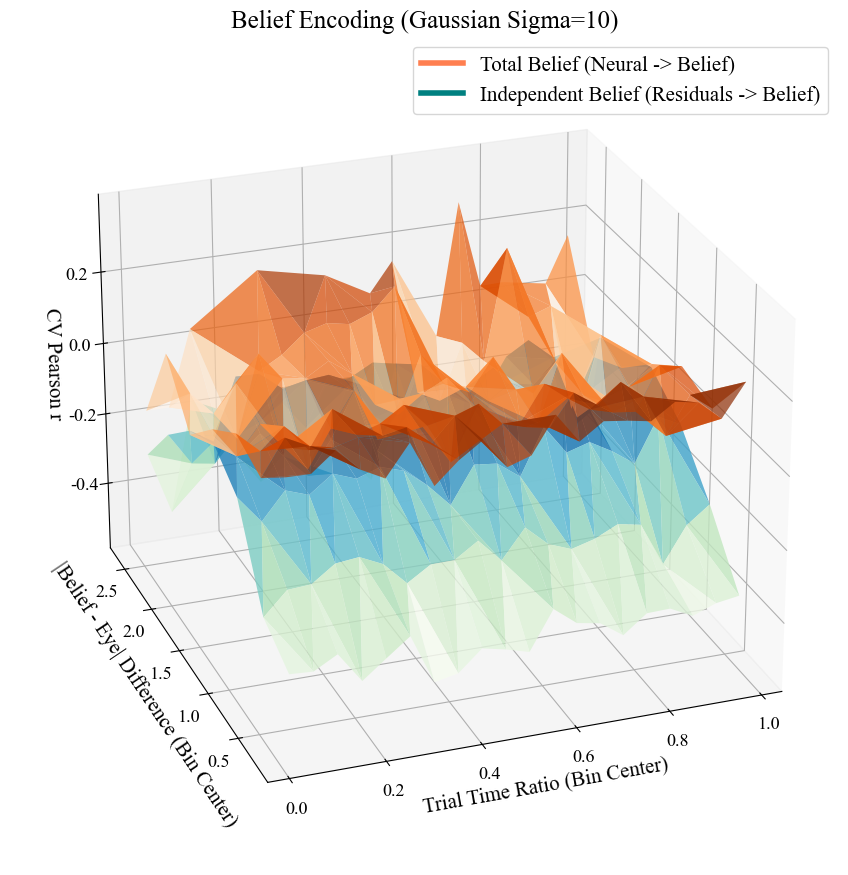


3D Surface Plot Analysis (Sigma=10) Complete.


In [39]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # Import 3D plotting tool
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score
from scipy.ndimage import gaussian_filter1d # For Gaussian smoothing
from matplotlib.lines import Line2D # For custom legend

# --- Load Your Actual Data ---
# Assume 'timedf' is a pandas DataFrame already loaded in your environment
# It should contain columns like 'PPC', 'belief', 'eye', and 'timeratio'.

# Example check (replace with your actual DataFrame name if different)
if 'timedf' not in locals():
     # Try to load placeholder if actual data not found
     print("Warning: DataFrame 'timedf' not found. Using placeholder data.")
     # --- Placeholder Data (REPLACE WITH YOUR ACTUAL DATA LOADING) ---
     rng = np.random.default_rng(42)
     n_samples_orig = 100000 # Need more samples for 2D binning
     n_features = 50      # Number of channels/neurons
     sampling_rate = 166 # Hz

     # --- Helper function for Z-scoring (needed for placeholder generation) ---
     def normalize_z_placeholder(data):
         """Placeholder normalize_z for simulation data generation."""
         data = np.asarray(data) # Ensure input is array
         data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)
         scaler = StandardScaler()
         if np.std(data) < 1e-9:
             return np.zeros_like(data)
         return scaler.fit_transform(data.reshape(-1, 1)).flatten()
     # --- End Helper function ---

     belief_signal_true = normalize_z_placeholder(rng.random(n_samples_orig) * 10)
     eye_signal_true = normalize_z_placeholder(rng.random(n_samples_orig) * 5)

     # *** MODIFIED LINES: Ensure arrays before multiplication ***
     belief_signal_correlated = normalize_z_placeholder(0.7 * np.asarray(belief_signal_true) + 0.3 * np.asarray(eye_signal_true) + rng.normal(0, 0.5, n_samples_orig))
     eye_signal_correlated = normalize_z_placeholder(0.3 * np.asarray(belief_signal_true) + 0.7 * np.asarray(eye_signal_true) + rng.normal(0, 0.5, n_samples_orig))
     # *** END MODIFIED LINES ***

     voltage_noise = rng.normal(0, 1.0, (n_samples_orig, n_features))
     belief_mod = belief_signal_correlated[:, np.newaxis] * 0.1
     eye_mod = eye_signal_correlated[:, np.newaxis] * 0.3
     neural_data_raw_voltage_sim = voltage_noise + belief_mod + eye_mod

     # Create timeratio signal for placeholder consistency
     samples_per_trial = 100
     n_trials = n_samples_orig // samples_per_trial
     n_samples_orig = n_trials * samples_per_trial # Adjust total samples to fit trials
     timeratio_signal = np.tile(np.linspace(0, 1, samples_per_trial, endpoint=False), n_trials)
     # Trim data to match adjusted n_samples_orig
     neural_data_raw_voltage_sim = neural_data_raw_voltage_sim[:n_samples_orig]
     belief_signal_correlated = belief_signal_correlated[:n_samples_orig]
     eye_signal_correlated = eye_signal_correlated[:n_samples_orig]


     timedf = pd.DataFrame({
         # Ensure PPC column contains numpy arrays if stacking later
         'PPC': [neural_data_raw_voltage_sim[i,:] for i in range(n_samples_orig)], # Store row-wise if stacking sample-wise later
         'belief': belief_signal_correlated,
         'eye': eye_signal_correlated,
         'timeratio': timeratio_signal
     })
     # --- End Placeholder Data ---
else:
    print("Using provided 'timedf' DataFrame.")


# --- Parameters ---
sampling_rate = 166 # Hz - IMPORTANT: Set this to your actual sampling rate
outlier_threshold_std = 4 # Z-score threshold for removing outliers
gaussian_sigma_samples = 10 # <<< INCREASED SMOOTHING >>> Std deviation of Gaussian kernel in SAMPLES
n_time_bins = 20 # Number of bins for timeratio
n_diff_bins = 10 # Number of bins for belief-eye difference
diff_cutoff = 4.0 # Maximum absolute difference to include before binning
min_samples_per_bin = 50 # Minimum samples required in a 2D bin for analysis

# --- Extract Raw Data ---
print("--- Extracting Raw Data from DataFrame ---")
try:
    # Stacking assumes 'PPC' contains iterable objects (like lists or arrays) of the same feature length
    neural_data_raw_voltage = np.stack(timedf['PPC'].to_numpy())
    belief_data_present_raw = timedf['belief'].to_numpy()
    eye_data_present_raw = timedf['eye'].to_numpy()
    timeratio_raw = timedf['timeratio'].to_numpy() # Extract timeratio
    print(f"Initial shapes: Neural={neural_data_raw_voltage.shape}, Belief={belief_data_present_raw.shape}, Eye={eye_data_present_raw.shape}, TimeRatio={timeratio_raw.shape}")

    if not (neural_data_raw_voltage.shape[0] == belief_data_present_raw.shape[0] == eye_data_present_raw.shape[0] == timeratio_raw.shape[0]):
        raise ValueError("Mismatch in number of samples between neural ('PPC'), belief, eye, or timeratio data.")

except KeyError as e:
    raise KeyError(f"Column not found in timedf: {e}. Ensure columns 'PPC', 'belief', 'eye', and 'timeratio' exist.")
except Exception as e:
    # Add more detail to the error message
    print(f"Error processing data columns. Check data types and structure in DataFrame. Error: {e}")
    # Example: Check the type of the first element in 'PPC' if it exists
    if 'PPC' in timedf.columns and len(timedf['PPC']) > 0:
        print(f"Type of first element in 'PPC': {type(timedf['PPC'].iloc[0])}")
    raise # Re-raise the exception


# --- Helper function for Z-scoring ---
def normalize_z(data):
    """Applies z-score normalization to a 1D array."""
    if isinstance(data, pd.Series):
        data = data.to_numpy()
    # Ensure data is numpy array before processing
    data = np.asarray(data)
    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0) # Replace NaN/Inf with 0 before scaling
    scaler = StandardScaler()
    if data.ndim == 1: # Reshape only if 1D
        if np.std(data) < 1e-9:
            print("Warning: Standard deviation is zero during normalization. Returning zeros.")
            return np.zeros_like(data)
        return scaler.fit_transform(data.reshape(-1, 1)).flatten()
    elif data.ndim == 0: # Handle scalar input
         return np.array([0.0]) # Return a single zero in an array
    else: # Handle unexpected dimensions
        print(f"Warning: normalize_z received data with unexpected shape {data.shape}. Returning original data.")
        return data


# --- Normalize Behavioral Data Globally ---
print("\n--- Normalizing Behavioral Data (Globally) ---")
belief_data_normalized = normalize_z(belief_data_present_raw)
eye_data_normalized = normalize_z(eye_data_present_raw)

# --- Outlier Removal (Based on Normalized Belief & Eye) ---
print(f"\n--- Removing Outliers (Threshold: +/- {outlier_threshold_std} std dev for Belief & Eye) ---")
task_vars_normalized = np.vstack([belief_data_normalized, eye_data_normalized]).T
mask_outliers = (np.abs(task_vars_normalized) < outlier_threshold_std).all(axis=1)

# Apply mask to all data types that need to stay aligned
neural_data_raw_voltage_cleaned = neural_data_raw_voltage[mask_outliers, :]
belief_data_present = belief_data_normalized[mask_outliers]
eye_data_present = eye_data_normalized[mask_outliers]
timeratio_present = timeratio_raw[mask_outliers] # Keep timeratio aligned

n_removed = len(belief_data_present_raw) - len(belief_data_present)
print(f"Removed {n_removed} outlier trials/samples ({n_removed / len(belief_data_present_raw) * 100:.2f}%).")
print(f"Data shape after cleaning: Neural={neural_data_raw_voltage_cleaned.shape}, Belief={belief_data_present.shape}, Eye={eye_data_present.shape}, TimeRatio={timeratio_present.shape}")

if len(belief_data_present) == 0:
    raise ValueError("All data removed as outliers. Check data or threshold.")

# =============================================================================
# Calculate Belief-Eye Difference & Apply Cutoff
# =============================================================================
print("\n--- Calculating Absolute Belief-Eye Difference & Applying Cutoff ---")
belief_eye_diff_all = np.abs(belief_data_present - eye_data_present)
# Create mask for difference cutoff
diff_mask_cutoff = belief_eye_diff_all <= diff_cutoff
print(f"  Applying cutoff: Keeping differences <= {diff_cutoff:.2f}")

# Apply cutoff mask to all data
neural_data_raw_voltage_cutoff = neural_data_raw_voltage_cleaned[diff_mask_cutoff, :]
belief_data_cutoff = belief_data_present[diff_mask_cutoff]
eye_data_cutoff = eye_data_present[diff_mask_cutoff]
timeratio_cutoff = timeratio_present[diff_mask_cutoff]
belief_eye_diff_cutoff = belief_eye_diff_all[diff_mask_cutoff]

n_diff_removed = len(belief_data_present) - len(belief_data_cutoff)
print(f"  Removed {n_diff_removed} samples due to difference cutoff ({n_diff_removed / len(belief_data_present) * 100:.2f}% of cleaned data).")
print(f"Data shape after difference cutoff: Neural={neural_data_raw_voltage_cutoff.shape}, Belief={belief_data_cutoff.shape}, Eye={eye_data_cutoff.shape}, TimeRatio={timeratio_cutoff.shape}")

if len(belief_data_cutoff) == 0:
    raise ValueError("All data removed after difference cutoff. Check cutoff value.")


# =============================================================================
# Gaussian Smoothing of Cutoff Raw Voltage Data
# =============================================================================
print(f"\n--- Applying Gaussian Smoothing (sigma = {gaussian_sigma_samples} samples) ---") # Sigma is now 10
neural_data_smoothed = gaussian_filter1d(neural_data_raw_voltage_cutoff,
                                         sigma=gaussian_sigma_samples,
                                         axis=0,
                                         mode='reflect')
print("Gaussian smoothing complete.")

# =============================================================================
# Z-score Smoothed Data Per Channel Globally
# =============================================================================
print("Z-scoring smoothed data per channel (Globally)...")
scaler_smooth = StandardScaler()
neural_data_processed = np.zeros_like(neural_data_smoothed)
for i in range(neural_data_smoothed.shape[1]):
    channel_data = neural_data_smoothed[:, i].reshape(-1, 1)
    if np.std(channel_data) > 1e-9:
        neural_data_processed[:, i] = scaler_smooth.fit_transform(channel_data).flatten()
    else:
        print(f"Warning: Channel {i} has zero standard deviation after smoothing. Outputting zeros.")
print("Z-scoring complete.")
print(f"Processed neural data shape: {neural_data_processed.shape}")


# =============================================================================
# 2D Binned Analysis (Time x Difference) - Storing results for 3D plot
# =============================================================================
print(f"\n--- 2D Binned Analysis for 3D Plot (Time: {n_time_bins} bins, Difference: {n_diff_bins} bins) ---")

# Define bins based on data *after* cutoff
time_bin_edges = np.linspace(0, 1, n_time_bins + 1)
time_bin_centers = (time_bin_edges[:-1] + time_bin_edges[1:]) / 2

# Use 0 to diff_cutoff for difference bins
diff_bin_edges = np.linspace(0, diff_cutoff, n_diff_bins + 1)
diff_bin_centers = (diff_bin_edges[:-1] + diff_bin_edges[1:]) / 2

# Lists to store valid results for plotting
plot_data_total = [] # Stores (time_center, diff_center, r_total)
plot_data_independent = [] # Stores (time_center, diff_center, r_independent)

# Initialize the base model and CV strategy
lr_model = LinearRegression()
n_splits = 5 # CV folds within each bin

# Loop through time bins
for i in range(n_time_bins):
    time_bin_start = time_bin_edges[i]
    time_bin_end = time_bin_edges[i+1]
    is_last_time_bin = (i == n_time_bins - 1)
    if is_last_time_bin:
        time_mask = (timeratio_cutoff >= time_bin_start) & (timeratio_cutoff <= time_bin_end)
    else:
        time_mask = (timeratio_cutoff >= time_bin_start) & (timeratio_cutoff < time_bin_end)

    # Loop through difference bins
    for j in range(n_diff_bins):
        diff_bin_start = diff_bin_edges[j]
        diff_bin_end = diff_bin_edges[j+1]
        # Use the pre-calculated difference array after cutoff
        diff_mask = (belief_eye_diff_cutoff >= diff_bin_start) & (belief_eye_diff_cutoff < diff_bin_end)

        # Combine masks
        bin_mask = time_mask & diff_mask

        # Select data for the current 2D bin
        neural_bin = neural_data_processed[bin_mask]
        belief_bin = belief_data_cutoff[bin_mask]
        eye_bin = eye_data_cutoff[bin_mask]
        n_samples_in_bin = len(belief_bin)

        # Check if enough samples for analysis and CV
        if n_samples_in_bin < max(min_samples_per_bin, n_splits):
            continue # Skip to next bin

        print(f"Processing Bin (T={i+1},D={j+1})... N={n_samples_in_bin}")

        # --- Perform CV analyses within the bin ---
        eye_bin_2d = eye_bin.reshape(-1, 1)
        current_n_splits = n_splits
        if n_samples_in_bin < current_n_splits: current_n_splits = max(2, n_samples_in_bin)
        cv_bin = KFold(n_splits=current_n_splits, shuffle=True, random_state=42)

        # --- 1. Total Belief Encoding (Neural -> Belief) ---
        r_total_bin = np.nan # Default to NaN
        try:
            predicted_belief_total_cv_bin = cross_val_predict(lr_model, neural_bin, belief_bin, cv=cv_bin)
            valid_indices_total = np.isfinite(belief_bin) & np.isfinite(predicted_belief_total_cv_bin)
            if np.sum(valid_indices_total) >= 2:
                r_total_bin, _ = pearsonr(belief_bin[valid_indices_total], predicted_belief_total_cv_bin[valid_indices_total])
        except ValueError: pass # Keep NaN if error

        # --- 2. Independent Belief Encoding (Residuals -> Belief) ---
        r_independent_bin = np.nan # Default to NaN
        try:
            predicted_neural_from_eye_cv_bin = cross_val_predict(lr_model, eye_bin_2d, neural_bin, cv=cv_bin)
            residuals_bin = neural_bin - predicted_neural_from_eye_cv_bin
            predicted_belief_independent_cv_bin = cross_val_predict(lr_model, residuals_bin, belief_bin, cv=cv_bin)
            valid_indices_independent = np.isfinite(belief_bin) & np.isfinite(predicted_belief_independent_cv_bin)
            if np.sum(valid_indices_independent) >= 2:
                r_independent_bin, _ = pearsonr(belief_bin[valid_indices_independent], predicted_belief_independent_cv_bin[valid_indices_independent])
        except ValueError: pass # Keep NaN if error

        # Store results if they are valid numbers
        if not np.isnan(r_total_bin):
            plot_data_total.append((time_bin_centers[i], diff_bin_centers[j], r_total_bin))
        if not np.isnan(r_independent_bin):
            plot_data_independent.append((time_bin_centers[i], diff_bin_centers[j], r_independent_bin))


# =============================================================================
# Plotting the 3D Surface Plot using plot_trisurf
# =============================================================================
print("\n--- Plotting 3D Surface Plot ---")

fig_3d_surf = plt.figure(figsize=(12, 9))
ax_3d_surf = fig_3d_surf.add_subplot(111, projection='3d')

# Plot surface for Total Belief Encoding
if plot_data_total:
    try:
        time_total, diff_total, r_total = zip(*plot_data_total)
        if len(time_total) >= 3: # Need at least 3 points for triangulation
            surf_total = ax_3d_surf.plot_trisurf(time_total, diff_total, r_total, cmap='Oranges', alpha=0.7,
                                                 linewidth=0.1, antialiased=True)
            print(f"Plotting Total Belief surface with {len(time_total)} points.")
        else:
            print("Not enough valid data points (>=3) to plot Total Belief surface.")
    except Exception as e:
        print(f"Error plotting Total Belief surface: {e}")
else:
    print("No valid data points computed for 'Total Belief'.")


# Plot surface for Independent Belief Encoding
if plot_data_independent:
    try:
        time_indep, diff_indep, r_indep = zip(*plot_data_independent)
        if len(time_indep) >= 3: # Need at least 3 points for triangulation
            surf_indep = ax_3d_surf.plot_trisurf(time_indep, diff_indep, r_indep, cmap='GnBu', alpha=0.8,
                                                 linewidth=0.1, antialiased=True)
            print(f"Plotting Independent Belief surface with {len(time_indep)} points.")
        else:
            print("Not enough valid data points (>=3) to plot Independent Belief surface.")
    except Exception as e:
        print(f"Error plotting Independent Belief surface: {e}")
else:
    print("No valid data points computed for 'Independent Belief'.")


# Setting labels and title
ax_3d_surf.set_xlabel('Trial Time Ratio (Bin Center)')
ax_3d_surf.set_ylabel('|Belief - Eye| Difference (Bin Center)')
ax_3d_surf.set_zlabel('CV Pearson r')
ax_3d_surf.set_title(f'Belief Encoding (Gaussian Sigma={gaussian_sigma_samples})')

# Adjust Z limit if needed
all_r_values = []
if 'plot_data_total' in locals() and plot_data_total: all_r_values.extend([r for _,_,r in plot_data_total])
if 'plot_data_independent' in locals() and plot_data_independent: all_r_values.extend([r for _,_,r in plot_data_independent])

if all_r_values:
    all_r = np.array(all_r_values)
    min_z = min(0, np.nanmin(all_r) - 0.1) if not np.all(np.isnan(all_r)) else 0
    max_z = max(0.1, np.nanmax(all_r) + 0.1) if not np.all(np.isnan(all_r)) else 0.1
    ax_3d_surf.set_zlim(min_z, max_z)
else:
     ax_3d_surf.set_zlim(0, 0.1) # Default limits if no data


# Create proxy artists for legend
legend_elements = [Line2D([0], [0], color='coral', lw=4, label='Total Belief (Neural -> Belief)'),
                   Line2D([0], [0], color='teal', lw=4, label='Independent Belief (Residuals -> Belief)')]
ax_3d_surf.legend(handles=legend_elements)


ax_3d_surf.view_init(elev=25., azim=-110) # Adjust viewing angle
plt.tight_layout()
plt.show()

print(f"\n3D Surface Plot Analysis (Sigma={gaussian_sigma_samples}) Complete.")
